# Electrode Porosity Feasibility Assessment

**Purpose.** This notebook is an initial, non-production feasibility check for a
battery-electrode manufacturer's question: can non-destructive process
measurements (optical emission spectroscopy, electrical traces, and thermal
imaging) predict electrode porosity well enough to be worth a proof-of-concept?
It is scoped to roughly three hours of work, per the assessment brief, and is
explicitly **not** a production model or an exhaustive modeling competition.

The central, testable question this notebook answers:

> Can the sensor measurements predict porosity for a held-out physical sample
> better than a constant (baseline) prediction, and does dimensionality
> reduction (PCA) change that result?

Two model passes are run on identical data and identical validation splits:

- **Pass 1 (ridge):** fold-fitted standardization + ridge regression on all
  usable original sensor features together.
- **Pass 2 (PCR):** fold-fitted standardization + PCA + ordinary linear
  regression on the retained principal components.

Neither pass fits a separate regression per sensor column, and Pass 2 is not
assumed to beat Pass 1 — the point is to compare them honestly.


## 1. Verified facts versus unknowns

**Verified from the supplied files (recomputed below in Section 5, not taken
on faith):**
- `Sample_Info.csv` provides one thickness/porosity reference record per
  sample, for a small number of physical samples.
- `Measurement_Data.csv` provides repeated sensor readings keyed by
  `sample_id` and `measurement_id`, with four sensor blocks: OES intensities,
  electrical voltage and current traces, and a flattened thermal image.
- `OES_Wavelengths.csv` maps each OES bin number to a wavelength in nm.

**Not established by the supplied files, and not assumed here:**
- The reference porosity measurement method, timing, and location relative to
  the sensor readings.
- What differentiates the repeated readings per sample (repeated scans?
  multiple physical locations? something else?), or whether they are ordered.
- Any parent-batch, sheet, or roll relationship between samples.
- Whether thickness will be available at prediction time in a real workflow.
- An acceptable error threshold for the customer's decision.
- The flattening order or pixel geometry of the thermal image, or the
  physical units of the electrical and thermal channels.

This notebook proceeds on explicit, labeled working assumptions (Section 2)
rather than waiting on these answers, and flags exactly what would need to
change if they turn out differently.


## 2. Working assumptions and their impact on this notebook

These are **my proposed analytical choices**, not confirmed facts or
instructions from the customer contact ("Christina"). I'm proceeding without
waiting for her answers, and labeling each choice so it's easy to revise.

| ID | Working assumption / unknown | Impact on this notebook | What changes if clarified differently |
|---|---|---|---|
| A1 | Each `sample_id` is treated as one sample and the best available validation unit. Independence across sample IDs is unverified. | One modeling row and one final evaluated prediction per sample. No individual-reading random split. | If samples share a parent sheet, roll, batch, or acquisition group relevant to deployment, rebuild both outer and inner splits at that grouping level and rerun evaluation. |
| A2 | The repeated readings are unordered repeated characterizations of one relevant sample state. They are not assumed independent. | Use a fixed per-feature mean within each sample. Inspect spread, but do not build a temporal model or treat row order as process progression. | If readings are different stages or materially different conditions, revisit aggregation and label alignment. Rerun downstream analysis rather than merely editing the narrative. |
| A3 | The provided porosity is a usable reference for the state characterized by that sample's sensor readings. Exact timing, location, and method remain unknown. | Join the provided label by `sample_id`; never use porosity as an input feature. Do not assume the reference is error-free. | Revisit sample/label matching, paired-specimen effects, or the scientific question if labels describe another location or state. Later measurement of a target is not itself feature leakage. |
| A4 | Corresponding sensor columns are comparable across readings and samples, including spectral, trace-index, and thermal-pixel alignment. | Average the same feature position across each sample's readings. | If alignment, units, gain, instrument configuration, or calibration differ, obtain the relevant metadata and revise preprocessing before interpreting averages or coefficients. |
| A5 | A comparable collection of readings will be available for a future sample. | Evaluate sample-level prediction from aggregated readings. Do not claim single-scan, real-time, or manufacturing-scale performance. | A single-scan or different acquisition-budget use case requires a revised representation and evaluation. |
| A6 | Thickness is present in the historical sample table, but its availability in the intended prediction workflow is unconfirmed. | Retain thickness for descriptive EDA, but exclude it from both primary model passes. | If thickness will genuinely be available at prediction time, a separately labeled sensor-plus-thickness comparison can be added using the same evaluation safeguards. Do not quietly replace the sensor-only results. |
| A7 | OES wavelength is in nm. Other measurement units, porosity units, and exact acquisition ordering are not fully specified. | Report errors in "provided porosity units." Use feature indices where physical axes are unknown. Preserve recorded values; do not assume a percentage conversion, watts, micrometers, frame geometry, or time interval. | Update units, axis labels, and any justified transformations only after confirmation. |
| A8 | There is no confirmed customer error tolerance or requirement to favor accuracy over interpretability. | Compare held-out error with constant baselines and discuss physical interpretation cautiously. Conclude preliminary feasibility, not customer acceptance. | Once an intended decision and tolerance are known, assess the observed errors against that requirement. |

**Status:** all eight items above are unconfirmed working assumptions, not
facts verified by Christina. They are recorded in machine-readable form in
`results/assumptions_register.csv` (written in Section 4) so they're easy to
update once answers come back.


## 3. Design choices, not experimental facts

A few things worth being explicit about, since they shape everything that
follows:

- **Having many readings does not mean having that many independently
  labeled samples.** Porosity was only measured once per physical sample, so
  the number of physical samples is the effective sample size for
  validation, however many raw sensor readings support each one.
- **Averaging reduces the rows, not the columns.** Aggregating readings per
  sample into one row per sample reduces the number of *rows*. It does not
  reduce the 2,304 sensor feature columns — that's what PCA (Pass 2) is for.
- **PCA reduces the feature representation for Pass 2; it does not create new
  labeled samples.** PCR can't manufacture more porosity labels than we have.
- **Starting with linear models (ridge, PCR) is a testable modeling choice,
  not an assumption that the true physical relationship is linear.** If
  neither linear pass beats a constant baseline, that's evidence worth
  reporting honestly, not proof that no relationship exists — it may mean a
  different representation, more data, or a nonlinear model is needed later.
- **Unknown thickness availability, not unknown timing alone, motivates
  excluding it from the primary predictors.** Porosity is the modeling
  target; being measured downstream/offline is compatible with its role as a
  label, not a leakage concern. Thickness is excluded because we don't know
  if it would exist at prediction time in the real workflow (A6), not
  because of timing relative to porosity.


## 4. Configuration

One configuration cell, with every tunable setting in one place. These are
the predefined choices from the build brief — a proposed default analysis
plan, not the result of trying options against outer-CV scores.

`TIE_TOLERANCE_MAE` is declared here (not derived from results): if two
hyperparameter candidates' inner-CV MAE are within this tolerance, we prefer
the *simpler* model — fewer PCA components for PCR, stronger regularization
(larger alpha) for ridge.


In [1]:
from pathlib import Path

# --- Reproducibility -------------------------------------------------------
RANDOM_STATE = 42

# --- Validation scheme -------------------------------------------------------
OUTER_FOLDS = 5
INNER_FOLDS = 3
RUN_LEAVE_ONE_SAMPLE_OUT = True

# --- Aggregation / scope -----------------------------------------------------
AGGREGATION = "mean"
TARGET_COLUMN = "porosity"
INCLUDE_THICKNESS = False  # primary passes are sensor-only; see A6

# --- Model search grids -------------------------------------------------------
RIDGE_ALPHAS = [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
PCA_COMPONENT_CANDIDATES = [1, 2, 3, 5]
PRIMARY_METRIC = "MAE"
TIE_TOLERANCE_MAE = 0.01  # porosity units; ties broken toward the simpler model

# --- Descriptive-only toggle (never reused as model preprocessing) -----------
RUN_DESCRIPTIVE_PCA = False

# --- Execution ---------------------------------------------------------------
N_JOBS = 1

# --- Paths ---------------------------------------------------------------
PROJECT_DIR = Path.cwd()
DATA_DIR_CANDIDATES = [PROJECT_DIR / "data", PROJECT_DIR]
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

REQUIRED_FILES = {
    "measurement": ["Measurement_Data.csv", "Measurement_Data.csv.gz"],
    "sample_info": ["Sample_Info.csv"],
    "oes_wavelengths": ["OES_Wavelengths.csv"],
}

print("Config loaded.")
print("Candidate data directories (checked in order):")
for c in DATA_DIR_CANDIDATES:
    print(" -", c)


Config loaded.
Candidate data directories (checked in order):
 - /home/user/Machine-Learning-Projects/porosity_feasibility/data
 - /home/user/Machine-Learning-Projects/porosity_feasibility


## 5. Imports and environment versions

Recording the actual installed versions used for this run (not a claim of
compatibility with untested versions).


In [2]:
import sys
import json
import hashlib
import platform
import re
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ENV_VERSIONS = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
}
for k, v in ENV_VERSIONS.items():
    print(f"{k}: {v}")


python: 3.11.15
platform: Linux-6.18.44-fc-v33-x86_64-with-glibc2.39
numpy: 2.4.6
pandas: 3.0.5
scikit-learn: 1.9.1
matplotlib: 3.11.2


## 6. Data loading and validation

Resolving `DATA_DIR` from the configured candidates, loading the three CSVs,
and recomputing the structural facts claimed in the build brief instead of
assuming them. Any missing file stops execution here rather than silently
synthesizing data.


In [3]:
def resolve_data_dir(candidates: list[Path], required: dict[str, list[str]]) -> Path:
    """Return the first candidate directory containing all required files.

    Does not mix files from different candidate directories: a candidate only
    qualifies if it alone contains every required file.
    """
    per_candidate_missing = {}
    for cand in candidates:
        missing = []
        for role, names in required.items():
            if not any((cand / n).exists() for n in names):
                missing.append(f"{role} (looked for {names})")
        if not missing:
            return cand
        per_candidate_missing[str(cand)] = missing
    detail = "\n".join(f"  {d}: missing {m}" for d, m in per_candidate_missing.items())
    raise FileNotFoundError(
        "Could not resolve a single data directory containing all required files.\n"
        + detail
    )


def md5_of(path: Path) -> str:
    """Return the MD5 hex digest of a file's contents, read in chunks."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES, REQUIRED_FILES)
print(f"Resolved DATA_DIR: {DATA_DIR}")

measurement_path = next(
    DATA_DIR / n for n in REQUIRED_FILES["measurement"] if (DATA_DIR / n).exists()
)
sample_info_path = DATA_DIR / "Sample_Info.csv"
oes_wavelengths_path = DATA_DIR / "OES_Wavelengths.csv"

resolved_paths = {
    "measurement": measurement_path,
    "sample_info": sample_info_path,
    "oes_wavelengths": oes_wavelengths_path,
}
file_hashes = {k: md5_of(v) for k, v in resolved_paths.items()}
for k, v in resolved_paths.items():
    print(f"{k}: {v.name}  (md5 {file_hashes[k]})")


def load_and_flag_export_index(path: Path) -> tuple[pd.DataFrame, list[str]]:
    """Load a CSV and identify (but not blindly drop) blank pandas export-index columns.

    A blank CSV header loads as 'Unnamed: 0'. We only treat such a column as an
    export index if its values are exactly 0..n-1, so we never drop a real
    column by position alone.
    """
    df = pd.read_csv(path)
    export_index_cols = []
    for col in df.columns:
        if col == "" or str(col).startswith("Unnamed:"):
            values = df[col].to_numpy()
            if np.array_equal(values, np.arange(len(df))):
                export_index_cols.append(col)
    return df, export_index_cols


measurement_raw, meas_export_idx = load_and_flag_export_index(measurement_path)
sample_info_raw, sample_export_idx = load_and_flag_export_index(sample_info_path)
oes_wavelengths_raw, oes_export_idx = load_and_flag_export_index(oes_wavelengths_path)

print("Measurement_Data raw shape:", measurement_raw.shape, "export-index cols:", meas_export_idx)
print("Sample_Info raw shape:", sample_info_raw.shape, "export-index cols:", sample_export_idx)
print("OES_Wavelengths raw shape:", oes_wavelengths_raw.shape, "export-index cols:", oes_export_idx)

measurement_raw = measurement_raw.drop(columns=meas_export_idx)
sample_info_raw = sample_info_raw.drop(columns=sample_export_idx)
oes_wavelengths_raw = oes_wavelengths_raw.drop(columns=oes_export_idx)

print("Measurement_Data columns after dropping export index:", measurement_raw.shape[1])
print("Sample_Info columns:", list(sample_info_raw.columns))
print("OES_Wavelengths columns:", list(oes_wavelengths_raw.columns))


Resolved DATA_DIR: /home/user/Machine-Learning-Projects/porosity_feasibility/data
measurement: Measurement_Data.csv.gz  (md5 76454547f3d50edb707a3e899621e6fc)
sample_info: Sample_Info.csv  (md5 acb0667cdf7c9aef5393b99dca584c86)
oes_wavelengths: OES_Wavelengths.csv  (md5 7b6b11e0467c52806c1a104caff8f40b)


Measurement_Data raw shape: (2000, 2307) export-index cols: ['Unnamed: 0']
Sample_Info raw shape: (20, 4) export-index cols: ['Unnamed: 0']
OES_Wavelengths raw shape: (256, 3) export-index cols: ['Unnamed: 0']
Measurement_Data columns after dropping export index: 2306
Sample_Info columns: ['sample_id', 'thickness', 'porosity']
OES_Wavelengths columns: ['Bin Number', 'Wavelength (nm)']


In [4]:
def sorted_block_columns(columns: list[str], prefix: str) -> list[str]:
    """Return columns matching '{prefix}_<int>', sorted numerically by the index."""
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matches = []
    for c in columns:
        m = pattern.match(c)
        if m:
            matches.append((int(m.group(1)), c))
    matches.sort(key=lambda t: t[0])
    return [c for _, c in matches]


FEATURE_BLOCKS = {
    "OES_bin": sorted_block_columns(measurement_raw.columns, "OES_bin"),
    "V_t": sorted_block_columns(measurement_raw.columns, "V_t"),
    "I_t": sorted_block_columns(measurement_raw.columns, "I_t"),
    "IR_pix": sorted_block_columns(measurement_raw.columns, "IR_pix"),
}
FEATURE_COLUMNS = sum(FEATURE_BLOCKS.values(), [])  # OES, then V_t, then I_t, then IR_pix
ID_COLUMNS = ["sample_id", "measurement_id"]

non_feature_non_id = [
    c for c in measurement_raw.columns if c not in FEATURE_COLUMNS and c not in ID_COLUMNS
]

for block, cols in FEATURE_BLOCKS.items():
    print(f"{block}: {len(cols)} columns")
print("Total sensor feature columns:", len(FEATURE_COLUMNS))
print("ID columns found:", [c for c in ID_COLUMNS if c in measurement_raw.columns])
print("Unrecognized non-feature, non-ID columns (should be empty):", non_feature_non_id)
assert not non_feature_non_id, "Found measurement columns that are neither a recognized sensor feature nor an ID column."
assert set(ID_COLUMNS).issubset(measurement_raw.columns), "Measurement data is missing an expected ID column."


OES_bin: 256 columns
V_t: 512 columns
I_t: 512 columns
IR_pix: 1024 columns
Total sensor feature columns: 2304
ID columns found: ['sample_id', 'measurement_id']
Unrecognized non-feature, non-ID columns (should be empty): []


### 6.1 Structural and integrity checks

Running the checks the brief calls for explicitly, rather than assuming the
data is clean. Anything unexpected is reported, not silently patched:
duplicate reference rows, mismatched sample IDs, non-numeric sensor values,
missing/infinite values, and export-index / ID / target leakage into the
predictor set.


In [5]:
audit_checks = []  # list of {"name": str, "passed": bool, "detail": str}


def record_check(name: str, passed: bool, detail: str) -> None:
    audit_checks.append({"name": name, "passed": bool(passed), "detail": detail})
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {name}: {detail}")


# --- Sample_Info: one row per sample_id, finite porosity -------------------
sample_id_counts = sample_info_raw["sample_id"].value_counts()
dup_sample_ids = sample_id_counts[sample_id_counts > 1]
record_check(
    "sample_info_one_row_per_id",
    dup_sample_ids.empty,
    f"{len(dup_sample_ids)} sample_id(s) with more than one Sample_Info row"
    + (f": {dup_sample_ids.to_dict()}" if not dup_sample_ids.empty else ""),
)

porosity_finite = np.isfinite(sample_info_raw[TARGET_COLUMN].to_numpy(dtype=float))
record_check(
    "sample_info_porosity_finite",
    bool(porosity_finite.all()),
    f"{int((~porosity_finite).sum())} of {len(sample_info_raw)} porosity values are missing/non-finite",
)

# --- Sample ID referential integrity between the two tables -----------------
measurement_ids_set = set(measurement_raw["sample_id"].unique())
reference_ids_set = set(sample_info_raw["sample_id"].unique())
unmatched_measurement_ids = sorted(measurement_ids_set - reference_ids_set)
unused_reference_ids = sorted(reference_ids_set - measurement_ids_set)
record_check(
    "sample_ids_cross_referenced",
    not unmatched_measurement_ids,
    f"unmatched measurement sample_ids (no reference row): {unmatched_measurement_ids}; "
    f"unused reference sample_ids (no measurement rows): {unused_reference_ids}",
)

# --- (sample_id, measurement_id) uniqueness ---------------------------------
pair_dupes = measurement_raw.duplicated(subset=["sample_id", "measurement_id"], keep=False)
record_check(
    "sample_measurement_id_pairs_unique",
    not pair_dupes.any(),
    f"{int(pair_dupes.sum())} rows share a (sample_id, measurement_id) pair with another row",
)

# --- Full-row duplicate content (reported, not dropped) ---------------------
full_row_dupes = measurement_raw.duplicated(keep=False)
record_check(
    "full_row_duplicates_reported_only",
    True,  # informational: never a failure condition, just a disclosure
    f"{int(full_row_dupes.sum())} fully duplicate rows found (not removed)",
)

# --- Sensor columns numeric, no silent coercion ------------------------------
non_numeric_sensor_cols = [
    c for c in FEATURE_COLUMNS if not pd.api.types.is_numeric_dtype(measurement_raw[c])
]
if non_numeric_sensor_cols:
    raise ValueError(
        "Non-numeric sensor columns found; refusing to silently coerce: "
        f"{non_numeric_sensor_cols}"
    )
record_check("sensor_columns_numeric", True, "all sensor feature columns loaded as numeric dtype")

# --- Missing / infinite values -----------------------------------------------
sensor_values = measurement_raw[FEATURE_COLUMNS].to_numpy(dtype=float)
n_missing = int(np.isnan(sensor_values).sum())
n_inf = int(np.isinf(sensor_values).sum())
record_check(
    "sensor_missing_value_count",
    True,
    f"{n_missing} missing (NaN) sensor values out of {sensor_values.size} "
    f"({n_missing / sensor_values.size:.4%})",
)
record_check(
    "sensor_infinite_value_count",
    True,
    f"{n_inf} infinite sensor values found; these are converted to missing (NaN) "
    "as an explicit, logged decision before any imputation",
)
if n_inf:
    measurement_raw[FEATURE_COLUMNS] = measurement_raw[FEATURE_COLUMNS].replace(
        [np.inf, -np.inf], np.nan
    )

# --- OES wavelength lookup integrity -----------------------------------------
bin_col, wav_col = "Bin Number", "Wavelength (nm)"
oes_bins_unique = oes_wavelengths_raw[bin_col].is_unique
oes_wav_finite = np.isfinite(oes_wavelengths_raw[wav_col].to_numpy(dtype=float)).all()
record_check(
    "oes_wavelength_lookup_valid",
    bool(oes_bins_unique and oes_wav_finite),
    f"bin numbers unique: {oes_bins_unique}; all wavelengths finite: {oes_wav_finite}",
)
oes_bin_to_wavelength = dict(zip(oes_wavelengths_raw[bin_col], oes_wavelengths_raw[wav_col]))
oes_bin_numbers_in_data = {int(c.split("_")[-1]) for c in FEATURE_BLOCKS["OES_bin"]}
oes_bins_without_lookup = sorted(oes_bin_numbers_in_data - set(oes_bin_to_wavelength))
record_check(
    "oes_bins_have_wavelength_mapping",
    not oes_bins_without_lookup,
    f"{len(oes_bins_without_lookup)} OES bins in the measurement data have no wavelength lookup entry",
)

# --- Non-predictor columns identified up front -------------------------------
EXCLUDED_FROM_X = set(ID_COLUMNS) | {TARGET_COLUMN, "thickness"}
record_check(
    "excluded_columns_declared",
    True,
    f"columns never entered into predictor matrix X: {sorted(EXCLUDED_FROM_X)}",
)

n_checks_failed = sum(1 for c in audit_checks if not c["passed"])
print(f"\n{len(audit_checks)} checks run, {n_checks_failed} failed.")


[PASS] sample_info_one_row_per_id: 0 sample_id(s) with more than one Sample_Info row
[PASS] sample_info_porosity_finite: 0 of 20 porosity values are missing/non-finite
[PASS] sample_ids_cross_referenced: unmatched measurement sample_ids (no reference row): []; unused reference sample_ids (no measurement rows): []
[PASS] sample_measurement_id_pairs_unique: 0 rows share a (sample_id, measurement_id) pair with another row


[PASS] full_row_duplicates_reported_only: 0 fully duplicate rows found (not removed)
[PASS] sensor_columns_numeric: all sensor feature columns loaded as numeric dtype


[PASS] sensor_missing_value_count: 0 missing (NaN) sensor values out of 4608000 (0.0000%)
[PASS] sensor_infinite_value_count: 0 infinite sensor values found; these are converted to missing (NaN) as an explicit, logged decision before any imputation
[PASS] oes_wavelength_lookup_valid: bin numbers unique: True; all wavelengths finite: True
[PASS] oes_bins_have_wavelength_mapping: 0 OES bins in the measurement data have no wavelength lookup entry
[PASS] excluded_columns_declared: columns never entered into predictor matrix X: ['measurement_id', 'porosity', 'sample_id', 'thickness']

11 checks run, 0 failed.


In [6]:
readings_per_sample = measurement_raw.groupby("sample_id").size()

data_audit = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "resolved_data_dir": str(DATA_DIR),
    "files": {
        k: {"name": v.name, "md5": file_hashes[k]} for k, v in resolved_paths.items()
    },
    "raw_shapes": {
        "measurement": list(measurement_raw.shape),
        "sample_info": list(sample_info_raw.shape),
        "oes_wavelengths": list(oes_wavelengths_raw.shape),
    },
    "feature_block_counts": {k: len(v) for k, v in FEATURE_BLOCKS.items()},
    "total_feature_columns": len(FEATURE_COLUMNS),
    "n_samples_in_measurement_data": int(measurement_raw["sample_id"].nunique()),
    "n_samples_in_sample_info": int(sample_info_raw["sample_id"].nunique()),
    "readings_per_sample": {
        "min": int(readings_per_sample.min()),
        "max": int(readings_per_sample.max()),
        "unique_values": sorted(int(v) for v in readings_per_sample.unique()),
    },
    "n_missing_sensor_values": n_missing,
    "n_infinite_sensor_values_converted_to_missing": n_inf,
    "checks": audit_checks,
    "n_checks_failed": n_checks_failed,
    "environment_versions": ENV_VERSIONS,
}

with open(RESULTS_DIR / "data_audit.json", "w") as f:
    json.dump(data_audit, f, indent=2)

print("Readings per sample - unique counts observed:", data_audit["readings_per_sample"]["unique_values"])
print("Wrote", RESULTS_DIR / "data_audit.json")


Readings per sample - unique counts observed: [100]
Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/data_audit.json


In [7]:
assumptions_register = pd.DataFrame(
    [
        {
            "id": "A1",
            "assumption": "Each sample_id is one sample and the validation unit; independence across samples is unverified.",
            "status": "unconfirmed",
            "notebook_impact": "One modeling row and one evaluated prediction per sample; no reading-level random split.",
            "revision_action": "If samples share a batch/sheet/roll relevant to deployment, rebuild outer and inner splits at that grouping level and rerun.",
        },
        {
            "id": "A2",
            "assumption": "The repeated readings per sample are unordered repeated characterizations, not assumed independent.",
            "status": "unconfirmed",
            "notebook_impact": "Fixed per-feature mean aggregation per sample; no temporal modeling of reading order.",
            "revision_action": "If readings represent different stages/conditions, revisit aggregation and rerun downstream analysis.",
        },
        {
            "id": "A3",
            "assumption": "Provided porosity is a usable reference for the sensor-characterized state; timing/location/method unknown.",
            "status": "unconfirmed",
            "notebook_impact": "Join label by sample_id; never used as a predictor; not assumed error-free.",
            "revision_action": "Revisit label matching or paired-specimen effects if labels describe a different location/state.",
        },
        {
            "id": "A4",
            "assumption": "Corresponding sensor columns are comparable across readings and samples (spectral/trace/pixel alignment).",
            "status": "unconfirmed",
            "notebook_impact": "Average the same feature position across a sample's readings.",
            "revision_action": "If alignment/units/calibration differ, obtain metadata and revise preprocessing before interpreting averages/coefficients.",
        },
        {
            "id": "A5",
            "assumption": "A comparable collection of readings will be available for a future sample.",
            "status": "unconfirmed",
            "notebook_impact": "Evaluate sample-level prediction from aggregated readings only.",
            "revision_action": "A single-scan or different acquisition budget requires a revised representation and evaluation.",
        },
        {
            "id": "A6",
            "assumption": "Thickness availability at prediction time (in the real workflow) is unconfirmed.",
            "status": "unconfirmed",
            "notebook_impact": "Thickness retained for descriptive EDA only; excluded from both primary model passes.",
            "revision_action": "If thickness will genuinely be available at prediction time, add a separately labeled sensor+thickness comparison scenario.",
        },
        {
            "id": "A7",
            "assumption": "OES wavelength is in nm; other units, porosity units, and acquisition ordering are not fully specified.",
            "status": "unconfirmed",
            "notebook_impact": "Report errors in provided porosity units; use feature indices where physical axes are unknown.",
            "revision_action": "Update units/axis labels/transformations only after confirmation.",
        },
        {
            "id": "A8",
            "assumption": "No confirmed customer error tolerance or accuracy-vs-interpretability preference.",
            "status": "unconfirmed",
            "notebook_impact": "Compare held-out error to constant baselines; conclude preliminary feasibility, not customer acceptance.",
            "revision_action": "Assess observed error against the tolerance once an intended decision and threshold are known.",
        },
    ]
)
assumptions_register.to_csv(RESULTS_DIR / "assumptions_register.csv", index=False)
print(f"Wrote {RESULTS_DIR / 'assumptions_register.csv'} with {len(assumptions_register)} rows.")
assumptions_register


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/assumptions_register.csv with 8 rows.


,id,assumption,status,notebook_impact,revision_action
0,A1,Each sample_id is one sample and the validatio...,unconfirmed,One modeling row and one evaluated prediction ...,If samples share a batch/sheet/roll relevant t...
1,A2,The repeated readings per sample are unordered...,unconfirmed,Fixed per-feature mean aggregation per sample;...,If readings represent different stages/conditi...
2,A3,Provided porosity is a usable reference for th...,unconfirmed,Join label by sample_id; never used as a predi...,Revisit label matching or paired-specimen effe...
3,A4,Corresponding sensor columns are comparable ac...,unconfirmed,Average the same feature position across a sam...,"If alignment/units/calibration differ, obtain ..."
4,A5,A comparable collection of readings will be av...,unconfirmed,Evaluate sample-level prediction from aggregat...,A single-scan or different acquisition budget ...
5,A6,Thickness availability at prediction time (in ...,unconfirmed,Thickness retained for descriptive EDA only; e...,If thickness will genuinely be available at pr...
6,A7,"OES wavelength is in nm; other units, porosity...",unconfirmed,Report errors in provided porosity units; use ...,Update units/axis labels/transformations only ...
7,A8,No confirmed customer error tolerance or accur...,unconfirmed,Compare held-out error to constant baselines; ...,Assess observed error against the tolerance on...


## 7. Raw repeatability, before aggregation

Before collapsing 100 readings per sample down to one row, a quick look at
how much those readings vary within a sample. This is descriptive only — the
shaded bands below are **spread among readings**, not a confidence interval
from independent observations (A2).

Samples are chosen deterministically (evenly spaced across the sorted sample
ID range) without looking at any model error, so this isn't cherry-picked.


Deterministically chosen sample_ids for repeatability inspection: [np.int64(0), np.int64(6), np.int64(13), np.int64(19)]


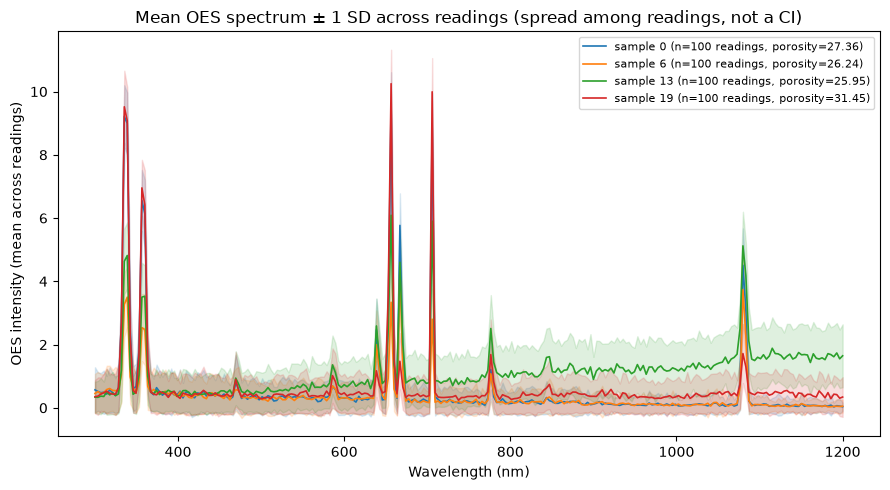

In [8]:
sample_ids_sorted = sorted(measurement_raw["sample_id"].unique())
n_pick = min(4, len(sample_ids_sorted))
pick_positions = np.linspace(0, len(sample_ids_sorted) - 1, n_pick).round().astype(int)
deterministic_sample_ids = sorted({sample_ids_sorted[p] for p in pick_positions})
print("Deterministically chosen sample_ids for repeatability inspection:", deterministic_sample_ids)

oes_cols_sorted = FEATURE_BLOCKS["OES_bin"]
wavelengths_sorted = np.array(
    [oes_bin_to_wavelength[int(c.split("_")[-1])] for c in oes_cols_sorted]
)

fig, ax = plt.subplots(figsize=(9, 5))
for sid in deterministic_sample_ids:
    rows = measurement_raw.loc[measurement_raw["sample_id"] == sid, oes_cols_sorted]
    mean_spectrum = rows.mean(axis=0).to_numpy()
    std_spectrum = rows.std(axis=0).to_numpy()
    porosity_val = sample_info_raw.loc[sample_info_raw["sample_id"] == sid, TARGET_COLUMN]
    label = f"sample {sid} (n={len(rows)} readings, porosity={porosity_val.iloc[0]:.2f})"
    line = ax.plot(wavelengths_sorted, mean_spectrum, label=label, linewidth=1.2)[0]
    ax.fill_between(
        wavelengths_sorted,
        mean_spectrum - std_spectrum,
        mean_spectrum + std_spectrum,
        color=line.get_color(),
        alpha=0.15,
    )
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("OES intensity (mean across readings)")
ax.set_title("Mean OES spectrum ± 1 SD across readings (spread among readings, not a CI)")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "oes_repeatability_selected_samples.png", dpi=150)
plt.show()


In [9]:
def block_coefficient_of_variation(sample_id: int, cols: list[str]) -> float:
    """Median |CoV| (std / |mean|) across a block's features, for one sample's readings.

    CoV is dimensionless, so unlike raw standard deviation it can be compared
    meaningfully across blocks with different physical units and scales.
    """
    rows = measurement_raw.loc[measurement_raw["sample_id"] == sample_id, cols]
    means = rows.mean(axis=0).to_numpy()
    stds = rows.std(axis=0).to_numpy()
    with np.errstate(divide="ignore", invalid="ignore"):
        cov = np.where(np.abs(means) > 1e-12, stds / np.abs(means), np.nan)
    return float(np.nanmedian(cov))


cov_records = []
for sid in sample_ids_sorted:
    for block, cols in FEATURE_BLOCKS.items():
        cov_records.append({"sample_id": sid, "block": block, "median_abs_cov": block_coefficient_of_variation(sid, cols)})
cov_df = pd.DataFrame(cov_records)

block_repeatability_summary = (
    cov_df.groupby("block")["median_abs_cov"]
    .agg(["median", "min", "max"])
    .reindex(FEATURE_BLOCKS.keys())
    .rename(columns={"median": "median_CoV_across_samples", "min": "min_CoV", "max": "max_CoV"})
)
print(
    "Within-sample spread by sensor block, summarized as the coefficient of "
    "variation (std / |mean|) so blocks with different units are comparable:"
)
block_repeatability_summary


Within-sample spread by sensor block, summarized as the coefficient of variation (std / |mean|) so blocks with different units are comparable:


,median_CoV_across_samples,min_CoV,max_CoV
block,,,
OES_bin,1.693935,0.814294,2.063703
V_t,0.030137,0.029139,0.030821
I_t,0.607916,0.110653,0.923140
IR_pix,0.032507,0.013802,2.481144


## 8. Aggregate once by sample

Computing each sensor column's arithmetic mean across that sample's
readings — a fixed, target-independent rule (A2), not something chosen by
trying alternatives against downstream CV scores. This is safe to do before
any train/test split: it only uses a given sample's own readings, never
other samples' statistics or the target. Everything downstream that is
*learned* (imputation, scaling, PCA) is fit inside training folds only.

This step reduces 2,000 readings to one row per sample. It does **not**
reduce the 2,304 sensor feature columns.


In [10]:
grouped = measurement_raw.groupby("sample_id")[FEATURE_COLUMNS]
sample_level_features = grouped.mean().reset_index().sort_values("sample_id").reset_index(drop=True)
sample_level_features_std = grouped.std().reset_index().sort_values("sample_id").reset_index(drop=True)
contributing_counts = grouped.count()  # per-feature non-missing reading count per sample

min_coverage = int(contributing_counts.to_numpy().min())
max_coverage = int(contributing_counts.to_numpy().max())
print(f"Readings contributing to each sample-feature mean: min={min_coverage}, max={max_coverage}")
if min_coverage != max_coverage:
    print("Coverage differs across samples/features — see contributing_counts for detail.")

# Reference table restricted to samples that actually have measurement data.
matched_ids = sorted(measurement_ids_set & reference_ids_set)
sample_reference_data = (
    sample_info_raw[sample_info_raw["sample_id"].isin(matched_ids)][["sample_id", "thickness", TARGET_COLUMN]]
    .sort_values("sample_id")
    .reset_index(drop=True)
)

merged_check = sample_level_features.merge(sample_reference_data, on="sample_id", how="inner")
assert len(merged_check) == len(sample_level_features) == len(sample_reference_data), (
    "Join between aggregated sensor features and sample reference data is not one-to-one."
)

sample_level_features = sample_level_features[sample_level_features["sample_id"].isin(matched_ids)].reset_index(drop=True)

X = sample_level_features[FEATURE_COLUMNS].copy()
y = sample_reference_data.set_index("sample_id").loc[sample_level_features["sample_id"], TARGET_COLUMN].to_numpy()
sample_ids_array = sample_level_features["sample_id"].to_numpy()

assert list(X.columns) == FEATURE_COLUMNS, "X column order does not match the declared feature order."
assert X.shape[0] == len(y) == len(sample_ids_array), "Row-count mismatch between X, y, and sample IDs."
assert not (set(X.columns) & EXCLUDED_FROM_X), "A non-predictor column leaked into X."

n_samples = X.shape[0]
n_features = X.shape[1]
remaining_missing_after_agg = int(X.isna().to_numpy().sum())
print(f"Aggregated to n_samples={n_samples}, n_features={n_features}")
print(f"Remaining missing values after sample-level averaging: {remaining_missing_after_agg}")

sample_level_features.to_csv(RESULTS_DIR / "sample_level_features.csv", index=False)
sample_reference_data.to_csv(RESULTS_DIR / "sample_reference_data.csv", index=False)
print(f"Wrote {RESULTS_DIR / 'sample_level_features.csv'} and {RESULTS_DIR / 'sample_reference_data.csv'}")


/tmp/ipykernel_509/649784537.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_level_features = grouped.mean().reset_index().sort_values("sample_id").reset_index(drop=True)
/tmp/ipykernel_509/649784537.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_level_features_std = grouped.std().reset_index().sort_values("sample_id").reset_index(drop=True)


Readings contributing to each sample-feature mean: min=100, max=100
Aggregated to n_samples=20, n_features=2304
Remaining missing values after sample-level averaging: 0
Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/sample_level_features.csv and /home/user/Machine-Learning-Projects/porosity_feasibility/results/sample_reference_data.csv


## 9. Focused sample-level EDA

All of this is descriptive: it uses the full 20-sample summary table to look
at the data, but none of it selects features, tunes hyperparameters, or
otherwise informs the modeling pipelines in Section 10-11. With only 20
sample summaries, correlations and visual patterns here are illustrative,
not statistically confirmed relationships.


,sample_id,thickness,porosity
0,0,92.17,27.36
1,1,70.68,26.89
2,2,83.67,20.26
3,3,93.86,28.91
4,4,92.64,31.02
5,5,66.23,28.34
6,6,85.75,26.24
7,7,75.73,28.55
8,8,78.25,25.95
9,9,68.24,19.96


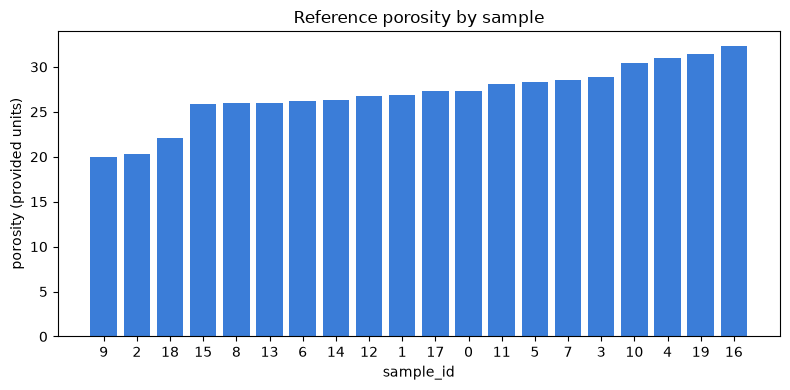

Porosity range across 20 samples: 19.96 to 32.34 (std 3.32)


In [11]:
display(sample_reference_data)

fig, ax = plt.subplots(figsize=(8, 4))
order = sample_reference_data.sort_values(TARGET_COLUMN)
ax.bar(order["sample_id"].astype(str), order[TARGET_COLUMN], color="#3b7dd8")
ax.set_xlabel("sample_id")
ax.set_ylabel("porosity (provided units)")
ax.set_title("Reference porosity by sample")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sample_porosity_overview.png", dpi=150)
plt.show()

print(
    f"Porosity range across {len(sample_reference_data)} samples: "
    f"{sample_reference_data[TARGET_COLUMN].min():.2f} to {sample_reference_data[TARGET_COLUMN].max():.2f} "
    f"(std {sample_reference_data[TARGET_COLUMN].std():.2f})"
)


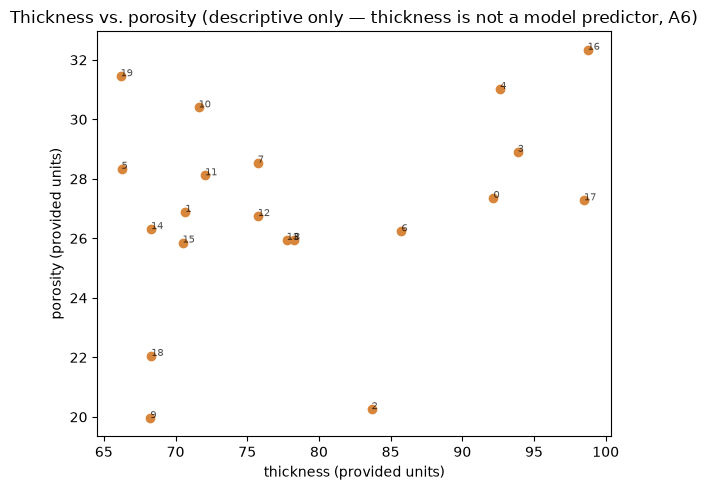

Descriptive Pearson correlation (thickness, porosity): 0.284 (n=20, not used for modeling)


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample_reference_data["thickness"], sample_reference_data[TARGET_COLUMN], color="#d8863b")
for _, row in sample_reference_data.iterrows():
    ax.annotate(str(int(row["sample_id"])), (row["thickness"], row[TARGET_COLUMN]), fontsize=7, alpha=0.7)
ax.set_xlabel("thickness (provided units)")
ax.set_ylabel("porosity (provided units)")
ax.set_title("Thickness vs. porosity (descriptive only — thickness is not a model predictor, A6)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "thickness_vs_porosity.png", dpi=150)
plt.show()

thickness_porosity_corr = sample_reference_data["thickness"].corr(sample_reference_data[TARGET_COLUMN])
print(f"Descriptive Pearson correlation (thickness, porosity): {thickness_porosity_corr:.3f} (n={len(sample_reference_data)}, not used for modeling)")


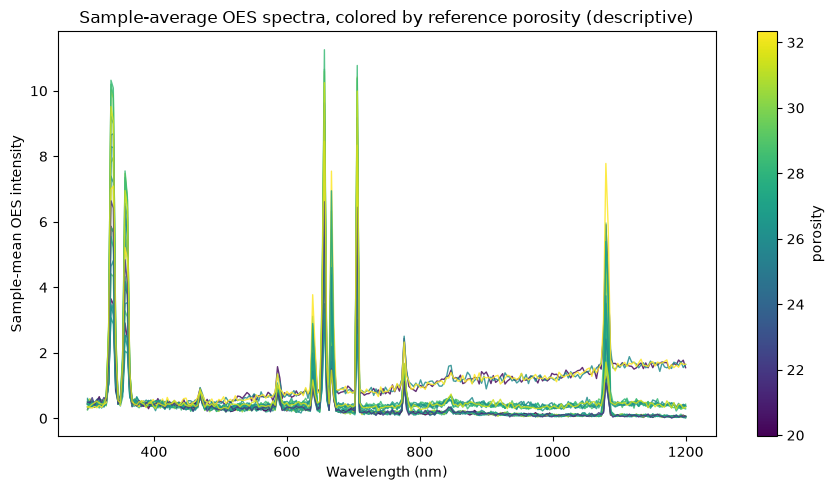

In [13]:
oes_sample_level = sample_level_features.set_index("sample_id")[oes_cols_sorted]
porosity_by_id = sample_reference_data.set_index("sample_id")[TARGET_COLUMN]

norm = plt.Normalize(porosity_by_id.min(), porosity_by_id.max())
cmap = plt.colormaps["viridis"]

fig, ax = plt.subplots(figsize=(9, 5))
for sid in oes_sample_level.index:
    ax.plot(
        wavelengths_sorted,
        oes_sample_level.loc[sid].to_numpy(),
        color=cmap(norm(porosity_by_id.loc[sid])),
        linewidth=1.0,
        alpha=0.85,
    )
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("porosity")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Sample-mean OES intensity")
ax.set_title("Sample-average OES spectra, colored by reference porosity (descriptive)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "oes_mean_spectra_by_porosity.png", dpi=150)
plt.show()


OES correlation heatmap uses every 8th bin: 32 of 256 bins.
This keeps the heatmap legible; it is not a full 256x256 feature screen.


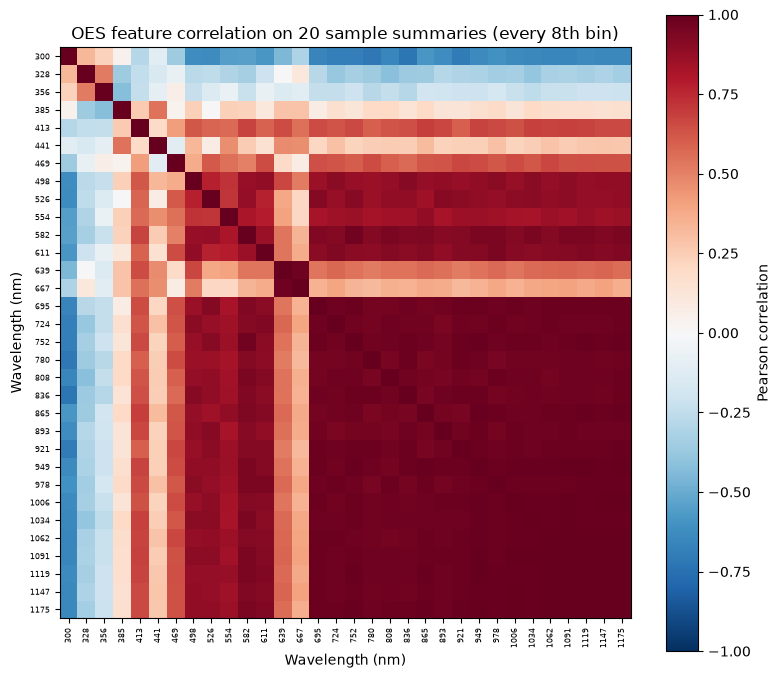

Feature-to-feature redundancy (this heatmap) is a separate question from manufacturing independence between samples (A1) — highly correlated wavelengths can still come from 20 independent, or non-independent, physical samples.


In [14]:
SUBSET_STRIDE = 8  # selection rule: every 8th OES bin, stated explicitly for reproducibility
oes_subset_cols = oes_cols_sorted[::SUBSET_STRIDE]
oes_subset_wavelengths = wavelengths_sorted[::SUBSET_STRIDE]
print(f"OES correlation heatmap uses every {SUBSET_STRIDE}th bin: {len(oes_subset_cols)} of {len(oes_cols_sorted)} bins.")
print("This keeps the heatmap legible; it is not a full 256x256 feature screen.")

corr_matrix = sample_level_features.set_index("sample_id")[oes_subset_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
tick_labels = [f"{w:.0f}" for w in oes_subset_wavelengths]
ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels, rotation=90, fontsize=6)
ax.set_yticks(range(len(tick_labels)))
ax.set_yticklabels(tick_labels, fontsize=6)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Wavelength (nm)")
ax.set_title(f"OES feature correlation on {n_samples} sample summaries (every {SUBSET_STRIDE}th bin)")
fig.colorbar(im, ax=ax, label="Pearson correlation")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "oes_correlation_heatmap.png", dpi=150)
plt.show()

print(
    "Feature-to-feature redundancy (this heatmap) is a separate question from "
    "manufacturing independence between samples (A1) — highly correlated "
    "wavelengths can still come from 20 independent, or non-independent, physical samples."
)


In [15]:
if RUN_DESCRIPTIVE_PCA:
    # Descriptive-only: fit on the full 20-sample table purely to look at it.
    # These objects (imputer/scaler/PCA) are separate from, and never reused
    # by, the evaluated Pass-2 pipelines in Section 11 — reusing a full-data
    # fit there would leak test information into every fold.
    desc_imputer = SimpleImputer(strategy="median")
    desc_scaler = StandardScaler()
    desc_pca = PCA(n_components=2, svd_solver="full", random_state=RANDOM_STATE)
    X_desc = desc_pca.fit_transform(desc_scaler.fit_transform(desc_imputer.fit_transform(X)))

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(X_desc[:, 0], X_desc[:, 1], c=y, cmap="viridis")
    fig.colorbar(sc, ax=ax, label="porosity")
    ax.set_xlabel("PC1 (descriptive, full-data fit)")
    ax.set_ylabel("PC2 (descriptive, full-data fit)")
    ax.set_title("Descriptive full-data PCA — never reused as model preprocessing")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "descriptive_pca_full_data.png", dpi=150)
    plt.show()
else:
    print("RUN_DESCRIPTIVE_PCA is False (default) — skipping the descriptive full-data PCA plot.")


RUN_DESCRIPTIVE_PCA is False (default) — skipping the descriptive full-data PCA plot.


## 10. Baselines and the two model passes

**Constant baselines.** Inside every outer training split, a training-mean
and a training-median `DummyRegressor` are fit — the bar the two real
passes need to clear. Neither baseline ever sees held-out targets.

**Shared training-only preprocessing.** Every learned transformation
(missing-value handling, dropping unusable/constant columns, standardization,
and — for Pass 2 — PCA) is fit on training rows only, inside each fold, using
scikit-learn pipelines:

```text
training-fitted all-missing/zero-variance column removal
→ training-fitted median imputation
→ StandardScaler
→ estimator (Ridge, or PCA + LinearRegression)
```

The all-missing/zero-variance check runs on the *raw* (pre-imputation)
training data — a column that's already constant after imputation could
otherwise hide a real problem. Per-feature standardization does **not** give
each sensor block equal total influence: OES (256 features), the electrical
traces (512 each), and thermal pixels (1,024) enter the model with very
different column counts. That's a limitation of this feature representation,
not evidence that thermal features matter four times more than OES.

**Pass 1 (ridge):** all usable original sensor columns together, tuning only
`alpha` over a predefined grid, `solver="svd"` for a stable fit on a wide,
small dataset. No PCA. Ridge stays a linear model — regularization addresses
the many-features/few-samples setting and collinearity, not "small numbers."

**Pass 2 (PCR):** the same columns, preprocessing, labels, and splits as
Pass 1, but with PCA (deterministic full SVD) inserted before an ordinary
`LinearRegression`, tuning only the number of components over a predefined
candidate set. PCA is unsupervised — a high-variance direction in the sensor
data is not necessarily predictive of porosity, so PCR is a comparison, not
a guaranteed upgrade over Pass 1.

**Tie-breaking rule (declared before seeing results):** if two hyperparameter
candidates' inner-CV MAE are within `TIE_TOLERANCE_MAE`, the simpler model is
preferred — fewer components for PCR, larger alpha (stronger regularization)
for ridge.


In [16]:
class ConstantColumnDropper(BaseEstimator, TransformerMixin):
    """Drops columns that are entirely missing or zero-variance, fit on training data only.

    Checked on the raw (pre-imputation) values: after imputation a
    previously all-missing column would look artificially constant, which
    would hide rather than flag the problem.
    """

    def fit(self, X: np.ndarray, y: np.ndarray | None = None) -> "ConstantColumnDropper":
        X = np.asarray(X, dtype=float)
        all_missing = np.all(np.isnan(X), axis=0)
        with np.errstate(invalid="ignore"):
            variances = np.nanvar(X, axis=0)
        zero_var = (~all_missing) & (np.nan_to_num(variances, nan=0.0) == 0.0)
        self.drop_mask_ = all_missing | zero_var
        self.n_dropped_all_missing_ = int(all_missing.sum())
        self.n_dropped_zero_variance_ = int(zero_var.sum())
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        return X[:, ~self.drop_mask_]

    def get_support(self) -> np.ndarray:
        return ~self.drop_mask_


def make_ridge_pipeline(alpha: float) -> Pipeline:
    """Fold-fitted preprocessing + ridge regression on original sensor features."""
    return Pipeline(
        [
            ("dropper", ConstantColumnDropper()),
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha, solver="svd", random_state=RANDOM_STATE)),
        ]
    )


def make_pcr_pipeline(n_components: int) -> Pipeline:
    """Fold-fitted preprocessing + PCA + ordinary linear regression (PCR)."""
    return Pipeline(
        [
            ("dropper", ConstantColumnDropper()),
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components, svd_solver="full", random_state=RANDOM_STATE)),
            ("linreg", LinearRegression()),
        ]
    )


def retained_feature_names(fitted_pipeline: Pipeline, original_columns: list[str]) -> list[str]:
    """Map a fitted pipeline's surviving columns back to their original feature names."""
    mask = fitted_pipeline.named_steps["dropper"].get_support()
    return [c for c, keep in zip(original_columns, mask) if keep]


print("Pipeline builders defined: make_ridge_pipeline(alpha), make_pcr_pipeline(n_components).")


Pipeline builders defined: make_ridge_pipeline(alpha), make_pcr_pipeline(n_components).


In [17]:
def pca_candidate_feasibility(
    X_train_raw: np.ndarray, candidates: list[int]
) -> tuple[list[int], list[int], int]:
    """Split PCA component candidates into feasible/infeasible for a training slice.

    The feasibility limit is min(surviving feature count after dropping
    all-missing/zero-variance columns, n_train_rows - 1) — the maximum
    number of nonzero principal components for centered data with more
    features than rows. Checked on training data only.
    """
    dropper = ConstantColumnDropper().fit(X_train_raw)
    n_features_after = int(dropper.get_support().sum())
    n_rows = X_train_raw.shape[0]
    limit = min(n_features_after, n_rows - 1)
    feasible = [c for c in candidates if c <= limit]
    infeasible = [c for c in candidates if c > limit]
    return feasible, infeasible, limit


print("pca_candidate_feasibility() defined.")


pca_candidate_feasibility() defined.


## 11. Validation: shared outer splits and inner tuning

**Primary scheme — 5-fold, sample-level `KFold(shuffle=True, random_state=RANDOM_STATE)`.**
With `n_samples` samples this trains on the majority of samples and holds
out the rest each fold. The outer splits are built once and reused
identically across both constant baselines and both model passes — every
model sees exactly the same held-out sample sets.

**Secondary sensitivity check — `LeaveOneOut`.** Same aggregated table, same
per-fold preprocessing and inner tuning, but not an independent replication:
it shares the dataset with the primary scheme and trains on more samples per
fold. Its results are kept under a separate scheme label rather than blended
into one headline number.

For every outer fold: the outer holdout's features and labels are never used
to fit transformations or choose settings. A 3-fold shuffled inner split
(deterministic, recorded seed) is built from the outer-training samples only,
and reused across the ridge and PCR searches. Each family's hyperparameter is
chosen by inner mean MAE, then that family's complete pipeline is refit on
the full outer-training set and used once to predict the outer holdout.

There is no permanent held-out test set here — "outer-CV held-out
predictions," not "unseen independent test-set results." Every sample gets
exactly one held-out prediction per model per scheme.


In [18]:
def build_outer_splits(scheme_name: str, splitter, positions: np.ndarray) -> list[dict]:
    """Build and validate one scheme's outer splits, recording sample IDs (not just positions)."""
    records = []
    for fold_id, (train_pos, test_pos) in enumerate(splitter.split(positions)):
        train_ids = sample_ids_array[train_pos].tolist()
        test_ids = sample_ids_array[test_pos].tolist()
        assert not (set(train_ids) & set(test_ids)), f"{scheme_name} fold {fold_id}: train/test sample overlap."
        assert set(train_ids) | set(test_ids) == set(sample_ids_array.tolist()), (
            f"{scheme_name} fold {fold_id}: train+test does not cover all samples."
        )
        records.append(
            {
                "fold_id": fold_id,
                "train_pos": train_pos.tolist(),
                "test_pos": test_pos.tolist(),
                "train_sample_ids": train_ids,
                "test_sample_ids": test_ids,
            }
        )
    return records


positions = np.arange(n_samples)

outer_splits_by_scheme = {
    "five_fold": build_outer_splits(
        "five_fold", KFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE), positions
    )
}
if RUN_LEAVE_ONE_SAMPLE_OUT:
    outer_splits_by_scheme["loo"] = build_outer_splits("loo", LeaveOneOut(), positions)

for scheme_name, folds in outer_splits_by_scheme.items():
    sizes = [(len(f["train_pos"]), len(f["test_pos"])) for f in folds]
    print(f"{scheme_name}: {len(folds)} outer folds, (train_size, test_size) per fold e.g. {sizes[0]}")

# Every sample must receive exactly one held-out prediction per scheme.
for scheme_name, folds in outer_splits_by_scheme.items():
    all_test_ids = [sid for f in folds for sid in f["test_sample_ids"]]
    assert sorted(all_test_ids) == sorted(sample_ids_array.tolist()), (
        f"{scheme_name}: outer folds do not give each sample exactly one held-out prediction."
    )
print("Outer-split coverage checks passed: every sample is held out exactly once per scheme.")


five_fold: 5 outer folds, (train_size, test_size) per fold e.g. (16, 4)
loo: 20 outer folds, (train_size, test_size) per fold e.g. (19, 1)
Outer-split coverage checks passed: every sample is held out exactly once per scheme.


In [19]:
def make_oof_row(scheme: str, model: str, fold_id: int, sample_id: int, actual: float, predicted: float) -> dict:
    """One out-of-fold prediction record. residual = actual - predicted, used consistently throughout."""
    residual = float(actual - predicted)
    return {
        "scheme": scheme,
        "model": model,
        "outer_fold": fold_id,
        "sample_id": int(sample_id),
        "actual_porosity": float(actual),
        "predicted_porosity": float(predicted),
        "residual": residual,
        "absolute_error": abs(residual),
        "squared_error": residual ** 2,
    }


In [20]:
def run_cv_scheme(scheme_name: str, outer_folds: list[dict]) -> dict:
    """Run baselines + tuned ridge + tuned PCR across one scheme's outer folds.

    For every outer fold: build inner splits from the outer-training samples
    only, tune ridge alpha and PCR n_components by inner MAE (with the
    declared tie-break rule), refit each family's full pipeline on the outer
    training set, and predict the outer holdout exactly once per model.
    Returns a dict of result DataFrames plus the fold-by-fold split record.
    """
    oof_rows, hparam_rows, inner_rows = [], [], []
    ridge_coef_rows, pcr_loading_rows = [], []
    splits_record = []

    for fold in outer_folds:
        fold_id = fold["fold_id"]
        train_pos = np.array(fold["train_pos"])
        test_pos = np.array(fold["test_pos"])
        train_ids = fold["train_sample_ids"]
        test_ids = fold["test_sample_ids"]

        X_train_df, X_test_df = X.iloc[train_pos], X.iloc[test_pos]
        y_train, y_test = y[train_pos], y[test_pos]

        # --- Inner splits: deterministic seed, built from outer-train only ---
        inner_seed = RANDOM_STATE * 1000 + fold_id
        n_inner = min(INNER_FOLDS, len(train_pos))
        inner_kf = KFold(n_splits=n_inner, shuffle=True, random_state=inner_seed)
        inner_splits = list(inner_kf.split(np.arange(len(train_pos))))

        inner_split_records = []
        for inner_fold_id, (itr, ite) in enumerate(inner_splits):
            itr_ids, ite_ids = [train_ids[i] for i in itr], [train_ids[i] for i in ite]
            assert not (set(itr_ids) & set(ite_ids)), "Inner train/test overlap."
            assert set(itr_ids) | set(ite_ids) <= set(train_ids), "Inner split leaked outside outer training samples."
            inner_split_records.append(
                {"inner_fold_id": inner_fold_id, "seed": inner_seed, "train_sample_ids": itr_ids, "test_sample_ids": ite_ids}
            )
        splits_record.append(
            {"fold_id": fold_id, "train_sample_ids": train_ids, "test_sample_ids": test_ids, "inner_splits": inner_split_records}
        )

        # --- Constant baselines, fit on training labels only ---
        for strategy in ["mean", "median"]:
            dummy = DummyRegressor(strategy=strategy).fit(X_train_df, y_train)
            for sid, actual, pred in zip(test_ids, y_test, dummy.predict(X_test_df)):
                oof_rows.append(make_oof_row(scheme_name, f"baseline_{strategy}", fold_id, sid, actual, pred))

        # --- Pass 1: ridge, tune alpha by inner MAE ---
        ridge_inner_scores = {a: [] for a in RIDGE_ALPHAS}
        for alpha in RIDGE_ALPHAS:
            for inner_fold_id, (itr, ite) in enumerate(inner_splits):
                pipe = make_ridge_pipeline(alpha).fit(X_train_df.iloc[itr], y_train[itr])
                mae = mean_absolute_error(y_train[ite], pipe.predict(X_train_df.iloc[ite]))
                ridge_inner_scores[alpha].append(mae)
                inner_rows.append({"scheme": scheme_name, "outer_fold": fold_id, "model": "ridge", "candidate": alpha, "inner_fold_id": inner_fold_id, "inner_mae": mae})
        ridge_mean = {a: float(np.mean(v)) for a, v in ridge_inner_scores.items()}
        best = min(ridge_mean.values())
        chosen_alpha = max(a for a, s in ridge_mean.items() if s <= best + TIE_TOLERANCE_MAE)  # tie -> stronger regularization

        ridge_final = make_ridge_pipeline(chosen_alpha).fit(X_train_df, y_train)
        for sid, actual, pred in zip(test_ids, y_test, ridge_final.predict(X_test_df)):
            oof_rows.append(make_oof_row(scheme_name, "ridge", fold_id, sid, actual, pred))
        hparam_rows.append({"scheme": scheme_name, "outer_fold": fold_id, "model": "ridge", "hyperparameter": "alpha", "value": chosen_alpha, "inner_mean_mae": ridge_mean[chosen_alpha]})
        retained = retained_feature_names(ridge_final, FEATURE_COLUMNS)
        for feat, coef in zip(retained, ridge_final.named_steps["ridge"].coef_):
            ridge_coef_rows.append({"scheme": scheme_name, "outer_fold": fold_id, "feature": feat, "coefficient": float(coef)})

        # --- Pass 2: PCR, feasibility-gated by the smallest inner training slice ---
        limits = []
        for itr, _ in inner_splits:
            raw = X_train_df.iloc[itr][FEATURE_COLUMNS].to_numpy(dtype=float)
            _, _, limit = pca_candidate_feasibility(raw, PCA_COMPONENT_CANDIDATES)
            limits.append(limit)
        feasibility_limit = min(limits)
        feasible = [c for c in PCA_COMPONENT_CANDIDATES if c <= feasibility_limit]
        excluded = [c for c in PCA_COMPONENT_CANDIDATES if c > feasibility_limit]
        if excluded:
            print(f"[{scheme_name} fold {fold_id}] PCA candidates excluded as infeasible (limit={feasibility_limit}): {excluded}")
        if not feasible:
            raise RuntimeError(f"No feasible PCA component candidates for {scheme_name} fold {fold_id} (limit={feasibility_limit}).")

        pcr_inner_scores = {c: [] for c in feasible}
        for c in feasible:
            for inner_fold_id, (itr, ite) in enumerate(inner_splits):
                pipe = make_pcr_pipeline(c).fit(X_train_df.iloc[itr], y_train[itr])
                mae = mean_absolute_error(y_train[ite], pipe.predict(X_train_df.iloc[ite]))
                pcr_inner_scores[c].append(mae)
                inner_rows.append({"scheme": scheme_name, "outer_fold": fold_id, "model": "pcr", "candidate": c, "inner_fold_id": inner_fold_id, "inner_mae": mae})
        pcr_mean = {c: float(np.mean(v)) for c, v in pcr_inner_scores.items()}
        best_pcr = min(pcr_mean.values())
        chosen_n_components = min(c for c, s in pcr_mean.items() if s <= best_pcr + TIE_TOLERANCE_MAE)  # tie -> fewer components

        pcr_final = make_pcr_pipeline(chosen_n_components).fit(X_train_df, y_train)
        for sid, actual, pred in zip(test_ids, y_test, pcr_final.predict(X_test_df)):
            oof_rows.append(make_oof_row(scheme_name, "pcr", fold_id, sid, actual, pred))
        hparam_rows.append({"scheme": scheme_name, "outer_fold": fold_id, "model": "pcr", "hyperparameter": "n_components", "value": chosen_n_components, "inner_mean_mae": pcr_mean[chosen_n_components], "excluded_candidates": str(excluded)})
        retained_pcr = retained_feature_names(pcr_final, FEATURE_COLUMNS)
        pca_step, linreg_step = pcr_final.named_steps["pca"], pcr_final.named_steps["linreg"]
        for comp_idx in range(pca_step.components_.shape[0]):
            for feat, loading in zip(retained_pcr, pca_step.components_[comp_idx]):
                pcr_loading_rows.append({"scheme": scheme_name, "outer_fold": fold_id, "component": comp_idx + 1, "feature": feat, "loading": float(loading), "component_regression_coef": float(linreg_step.coef_[comp_idx])})

    return {
        "oof": pd.DataFrame(oof_rows),
        "hparams": pd.DataFrame(hparam_rows),
        "inner": pd.DataFrame(inner_rows),
        "ridge_coefs": pd.DataFrame(ridge_coef_rows),
        "pcr_loadings": pd.DataFrame(pcr_loading_rows),
        "splits_record": splits_record,
    }


print("run_cv_scheme() defined.")


run_cv_scheme() defined.


In [21]:
scheme_results = {}
for scheme_name, folds in outer_splits_by_scheme.items():
    print(f"\n=== Running scheme: {scheme_name} ({len(folds)} outer folds) ===")
    scheme_results[scheme_name] = run_cv_scheme(scheme_name, folds)

oof_predictions = pd.concat([r["oof"] for r in scheme_results.values()], ignore_index=True)
selected_hyperparameters = pd.concat([r["hparams"] for r in scheme_results.values()], ignore_index=True)
inner_cv_results = pd.concat([r["inner"] for r in scheme_results.values()], ignore_index=True)
ridge_coefficients = pd.concat([r["ridge_coefs"] for r in scheme_results.values()], ignore_index=True)
pcr_component_loadings = pd.concat([r["pcr_loadings"] for r in scheme_results.values()], ignore_index=True)

# --- Acceptance checks: every sample exactly once per model per scheme, identical holdout sets ---
for scheme_name in scheme_results:
    sub = oof_predictions[oof_predictions["scheme"] == scheme_name]
    counts = sub.groupby(["model", "sample_id"]).size()
    assert (counts == 1).all(), f"{scheme_name}: some (model, sample_id) pair has != 1 prediction."
    per_model_sample_sets = sub.groupby("model")["sample_id"].apply(lambda s: frozenset(s))
    assert per_model_sample_sets.nunique() == 1, f"{scheme_name}: models saw different held-out sample sets."
print("Checked: every (scheme, model, sample_id) has exactly one prediction; held-out sets match across models within a scheme.")

cv_splits_payload = {
    scheme_name: scheme_results[scheme_name]["splits_record"] for scheme_name in scheme_results
}
with open(RESULTS_DIR / "cv_splits.json", "w") as f:
    json.dump(cv_splits_payload, f, indent=2)

oof_predictions.to_csv(RESULTS_DIR / "oof_predictions.csv", index=False)
selected_hyperparameters.to_csv(RESULTS_DIR / "selected_hyperparameters.csv", index=False)
inner_cv_results.to_csv(RESULTS_DIR / "inner_cv_results.csv", index=False)
ridge_coefficients.to_csv(RESULTS_DIR / "ridge_coefficients.csv", index=False)
pcr_component_loadings.to_csv(RESULTS_DIR / "pcr_component_loadings.csv", index=False)

print(f"oof_predictions: {oof_predictions.shape}")
print(f"selected_hyperparameters: {selected_hyperparameters.shape}")
print(f"inner_cv_results: {inner_cv_results.shape}")
print("Wrote cv_splits.json, oof_predictions.csv, selected_hyperparameters.csv, inner_cv_results.csv,")
print("ridge_coefficients.csv, pcr_component_loadings.csv")



=== Running scheme: five_fold (5 outer folds) ===



=== Running scheme: loo (20 outer folds) ===


Checked: every (scheme, model, sample_id) has exactly one prediction; held-out sets match across models within a scheme.


oof_predictions: (160, 9)
selected_hyperparameters: (50, 7)
inner_cv_results: (750, 6)
Wrote cv_splits.json, oof_predictions.csv, selected_hyperparameters.csv, inner_cv_results.csv,
ridge_coefficients.csv, pcr_component_loadings.csv


## 12. Metrics

MAE is the primary metric (declared in Section 4, before any results were
seen). RMSE is secondary. Pooled out-of-fold R² is a supplementary
descriptive summary — computed once from all pooled held-out predictions,
not averaged across per-fold R² values, and left as `NaN` for folds with a
single held-out sample (leave-one-out), where R² isn't meaningful.


In [22]:
def compute_fold_metrics(oof: pd.DataFrame) -> pd.DataFrame:
    """Per (scheme, model, outer_fold) MAE/RMSE, with R2 left NaN for single-sample folds."""
    records = []
    for (scheme, model, fold_id), grp in oof.groupby(["scheme", "model", "outer_fold"]):
        n_test = len(grp)
        mae = mean_absolute_error(grp["actual_porosity"], grp["predicted_porosity"])
        rmse = float(np.sqrt(np.mean(grp["squared_error"])))
        r2 = r2_score(grp["actual_porosity"], grp["predicted_porosity"]) if n_test > 1 else np.nan
        records.append({"scheme": scheme, "model": model, "outer_fold": fold_id, "n_test_samples": n_test, "mae": mae, "rmse": rmse, "r2": r2})
    return pd.DataFrame(records).sort_values(["scheme", "model", "outer_fold"]).reset_index(drop=True)


fold_metrics = compute_fold_metrics(oof_predictions)
fold_metrics.to_csv(RESULTS_DIR / "fold_metrics.csv", index=False)
print(f"Wrote {RESULTS_DIR / 'fold_metrics.csv'} ({fold_metrics.shape[0]} rows)")
fold_metrics.head(10)


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/fold_metrics.csv (100 rows)


,scheme,model,outer_fold,n_test_samples,mae,rmse,r2
0,five_fold,baseline_mean,0,4,0.472500,0.626713,-0.101214
1,five_fold,baseline_mean,1,4,1.459063,1.529364,-0.854473
2,five_fold,baseline_mean,2,4,4.750938,5.177771,-0.249004
3,five_fold,baseline_mean,3,4,3.940000,4.631000,-0.006403
4,five_fold,baseline_mean,4,4,1.600000,2.045992,-0.400765
5,five_fold,baseline_median,0,4,0.587500,0.837750,-0.967722
6,five_fold,baseline_median,1,4,1.445000,1.510414,-0.808801
7,five_fold,baseline_median,2,4,4.680000,5.115999,-0.219380
8,five_fold,baseline_median,3,4,3.940000,4.621020,-0.002069
9,five_fold,baseline_median,4,4,1.600000,1.900664,-0.208839


In [23]:
def compute_pooled_metrics(oof: pd.DataFrame) -> pd.DataFrame:
    """Pooled MAE/RMSE/R2 per (scheme, model) from the complete set of held-out predictions,
    plus the MAE difference from each constant baseline on the same held-out samples."""
    records = []
    for (scheme, model), grp in oof.groupby(["scheme", "model"]):
        mae = mean_absolute_error(grp["actual_porosity"], grp["predicted_porosity"])
        rmse = float(np.sqrt(np.mean(grp["squared_error"])))
        actual_var = np.var(grp["actual_porosity"])
        r2 = r2_score(grp["actual_porosity"], grp["predicted_porosity"]) if actual_var > 0 else np.nan
        records.append({"scheme": scheme, "model": model, "n_predictions": len(grp), "MAE": mae, "RMSE": rmse, "pooled_R2": r2})
    summary = pd.DataFrame(records)

    baseline_mae = {
        (row.scheme, "mean"): row.MAE
        for row in summary[summary["model"] == "baseline_mean"].itertuples()
    }
    baseline_mae.update(
        {(row.scheme, "median"): row.MAE for row in summary[summary["model"] == "baseline_median"].itertuples()}
    )
    summary["mae_diff_vs_mean_baseline"] = summary.apply(lambda r: r["MAE"] - baseline_mae[(r["scheme"], "mean")], axis=1)
    summary["mae_diff_vs_median_baseline"] = summary.apply(lambda r: r["MAE"] - baseline_mae[(r["scheme"], "median")], axis=1)
    return summary.sort_values(["scheme", "model"]).reset_index(drop=True)


metrics_summary = compute_pooled_metrics(oof_predictions)
metrics_summary.to_csv(RESULTS_DIR / "metrics_summary.csv", index=False)
print(f"Wrote {RESULTS_DIR / 'metrics_summary.csv'}")
metrics_summary


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/metrics_summary.csv


,scheme,model,n_predictions,MAE,RMSE,pooled_R2,mae_diff_vs_mean_baseline,mae_diff_vs_median_baseline
0,five_fold,baseline_mean,20,2.444500,3.321845,-0.053570,0.000000,-0.006000
1,five_fold,baseline_median,20,2.450500,3.290075,-0.033514,0.006000,0.000000
2,five_fold,pcr,20,2.476852,2.993864,0.144207,0.032352,0.026352
3,five_fold,ridge,20,2.889862,3.456270,-0.140565,0.445362,0.439362
4,loo,baseline_mean,20,2.502632,3.406623,-0.108033,0.000000,-0.069868
5,loo,baseline_median,20,2.572500,3.383215,-0.092858,0.069868,0.000000
6,loo,pcr,20,2.726059,3.190240,0.028257,0.223427,0.153559
7,loo,ridge,20,2.453399,3.163680,0.044370,-0.049232,-0.119101


In [24]:
reloaded_oof = pd.read_csv(RESULTS_DIR / "oof_predictions.csv")
reloaded_summary = pd.read_csv(RESULTS_DIR / "metrics_summary.csv").set_index(["scheme", "model"])
recomputed = compute_pooled_metrics(reloaded_oof).set_index(["scheme", "model"])

mismatches = []
for key in reloaded_summary.index:
    for col in ["MAE", "RMSE"]:
        a, b = reloaded_summary.loc[key, col], recomputed.loc[key, col]
        if not np.isclose(a, b, atol=1e-9):
            mismatches.append((key, col, a, b))

assert not mismatches, f"metrics_summary.csv does not match metrics recomputed from oof_predictions.csv: {mismatches}"
print("PASS: metrics recomputed from the saved oof_predictions.csv exactly match the saved metrics_summary.csv.")


PASS: metrics recomputed from the saved oof_predictions.csv exactly match the saved metrics_summary.csv.


## 13. Customer-readable figures

A compact set of figures, each captioned to say plainly whether it's
descriptive EDA or held-out predictive evaluation.


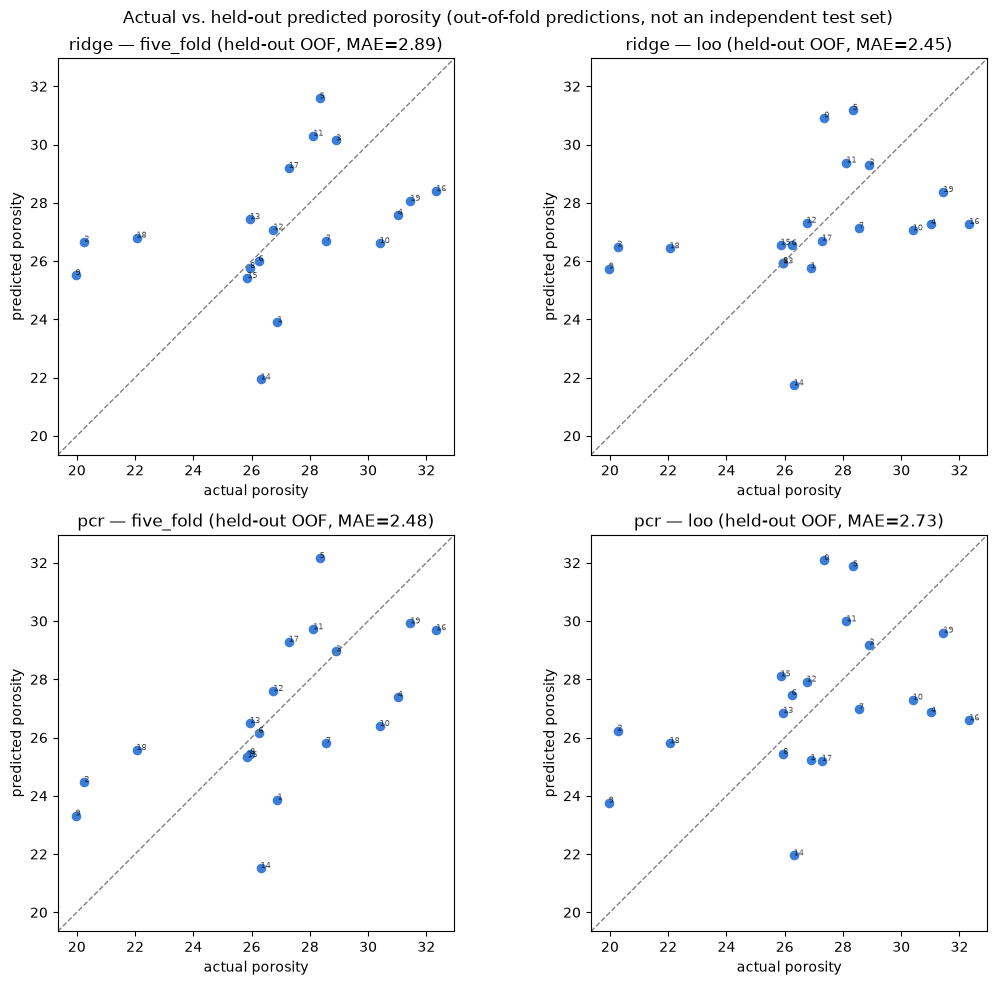

In [25]:
schemes_present = list(outer_splits_by_scheme.keys())
models_primary = ["ridge", "pcr"]

fig, axes = plt.subplots(len(models_primary), len(schemes_present), figsize=(5.5 * len(schemes_present), 5 * len(models_primary)), squeeze=False)

lo, hi = oof_predictions["actual_porosity"].min(), oof_predictions["actual_porosity"].max()
pad = 0.05 * (hi - lo)
axis_limits = (lo - pad, hi + pad)

for row, model in enumerate(models_primary):
    for col, scheme in enumerate(schemes_present):
        ax = axes[row][col]
        sub = oof_predictions[(oof_predictions["scheme"] == scheme) & (oof_predictions["model"] == model)]
        ax.plot(axis_limits, axis_limits, linestyle="--", color="gray", linewidth=1, label="identity")
        ax.scatter(sub["actual_porosity"], sub["predicted_porosity"], color="#3b7dd8", s=35)
        for _, r in sub.iterrows():
            ax.annotate(str(int(r["sample_id"])), (r["actual_porosity"], r["predicted_porosity"]), fontsize=6, alpha=0.7)
        ax.set_xlim(axis_limits)
        ax.set_ylim(axis_limits)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("actual porosity")
        ax.set_ylabel("predicted porosity")
        mae_here = metrics_summary.set_index(["scheme", "model"]).loc[(scheme, model), "MAE"]
        ax.set_title(f"{model} — {scheme} (held-out OOF, MAE={mae_here:.2f})")

fig.suptitle("Actual vs. held-out predicted porosity (out-of-fold predictions, not an independent test set)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "actual_vs_predicted.png", dpi=150)
plt.show()


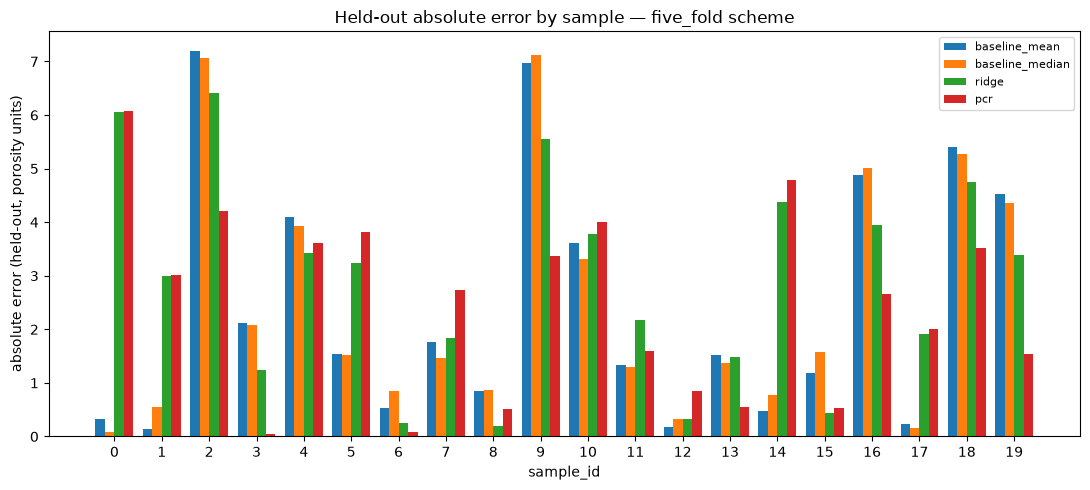

Samples with the largest held-out error (ridge or pcr, five_fold scheme):
sample_id
2     6.408424
0     6.080767
9     5.557002
14    4.787737
18    4.754175
dtype: float64


In [26]:
primary_scheme = "five_fold"
models_all = ["baseline_mean", "baseline_median", "ridge", "pcr"]
pivot = (
    oof_predictions[oof_predictions["scheme"] == primary_scheme]
    .pivot(index="sample_id", columns="model", values="absolute_error")
    .reindex(columns=models_all)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(pivot))
width = 0.8 / len(models_all)
for i, model in enumerate(models_all):
    ax.bar(x + i * width, pivot[model], width=width, label=model)
ax.set_xticks(x + width * (len(models_all) - 1) / 2)
ax.set_xticklabels(pivot.index.astype(int).astype(str))
ax.set_xlabel("sample_id")
ax.set_ylabel("absolute error (held-out, porosity units)")
ax.set_title(f"Held-out absolute error by sample — {primary_scheme} scheme")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "absolute_error_by_sample.png", dpi=150)
plt.show()

concentration = pivot[["ridge", "pcr"]].max(axis=1).sort_values(ascending=False)
print("Samples with the largest held-out error (ridge or pcr, five_fold scheme):")
print(concentration.head(5))


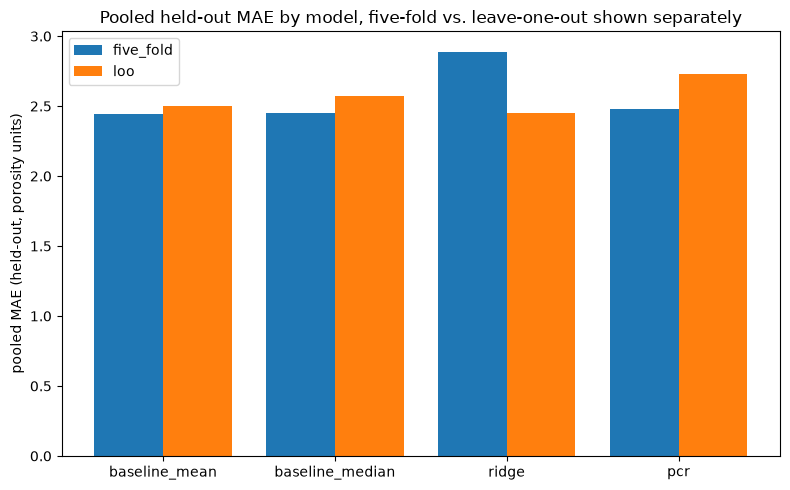

scheme,five_fold,loo
model,,
baseline_mean,2.444500,2.502632
baseline_median,2.450500,2.572500
ridge,2.889862,2.453399
pcr,2.476852,2.726059


In [27]:
mae_pivot = metrics_summary.pivot(index="model", columns="scheme", values="MAE").reindex(models_all)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(mae_pivot))
width = 0.8 / len(schemes_present)
for i, scheme in enumerate(schemes_present):
    ax.bar(x + i * width, mae_pivot[scheme], width=width, label=scheme)
ax.set_xticks(x + width * (len(schemes_present) - 1) / 2)
ax.set_xticklabels(mae_pivot.index)
ax.set_ylabel("pooled MAE (held-out, porosity units)")
ax.set_title("Pooled held-out MAE by model, five-fold vs. leave-one-out shown separately")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "mae_comparison.png", dpi=150)
plt.show()

mae_pivot


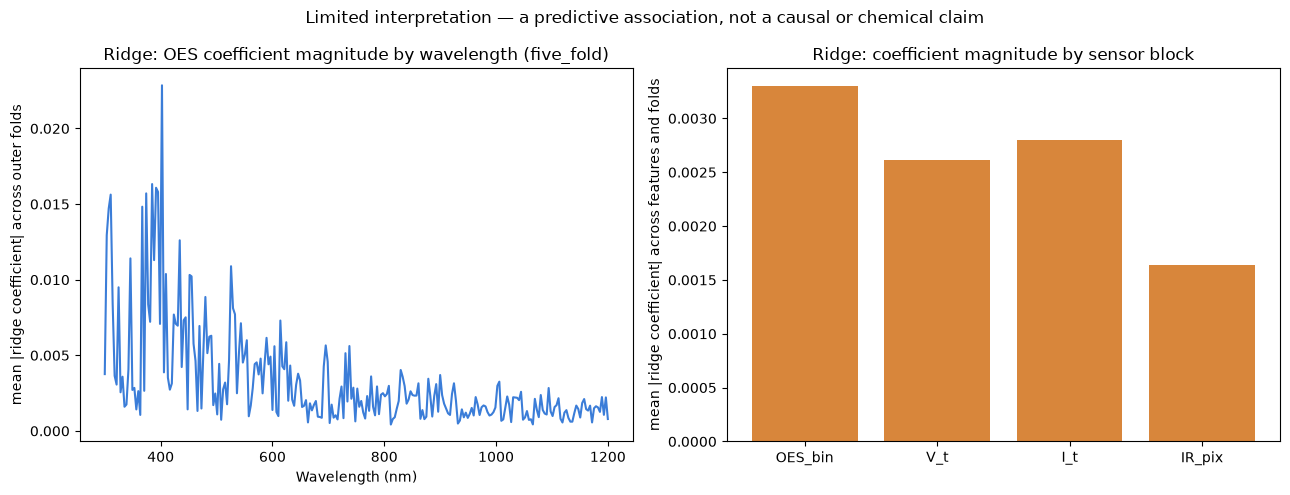

In [28]:
ridge_five_fold = ridge_coefficients[ridge_coefficients["scheme"] == primary_scheme].copy()


def feature_block(name: str) -> str:
    for block in FEATURE_BLOCKS:
        if name.startswith(block + "_"):
            return block
    return "other"


ridge_five_fold["block"] = ridge_five_fold["feature"].map(feature_block)
ridge_five_fold["abs_coef"] = ridge_five_fold["coefficient"].abs()

# Mean |coefficient| per OES feature across outer folds (features dropped in some
# folds simply contribute fewer values to that feature's average).
oes_only = ridge_five_fold[ridge_five_fold["block"] == "OES_bin"].copy()
oes_only["bin_number"] = oes_only["feature"].str.extract(r"OES_bin_(\d+)").astype(int)
oes_only["wavelength"] = oes_only["bin_number"].map(oes_bin_to_wavelength)
oes_mean_abs_coef = oes_only.groupby("wavelength")["abs_coef"].mean().sort_index()

block_mean_abs_coef = ridge_five_fold.groupby("block")["abs_coef"].mean().reindex(FEATURE_BLOCKS.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(oes_mean_abs_coef.index, oes_mean_abs_coef.to_numpy(), color="#3b7dd8")
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("mean |ridge coefficient| across outer folds")
ax1.set_title(f"Ridge: OES coefficient magnitude by wavelength ({primary_scheme})")

ax2.bar(block_mean_abs_coef.index, block_mean_abs_coef.to_numpy(), color="#d8863b")
ax2.set_ylabel("mean |ridge coefficient| across features and folds")
ax2.set_title("Ridge: coefficient magnitude by sensor block")

fig.suptitle("Limited interpretation — a predictive association, not a causal or chemical claim")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ridge_coefficient_interpretation.png", dpi=150)
plt.show()


In [29]:
top_block = block_mean_abs_coef.idxmax()
top_wavelength_row = oes_mean_abs_coef.idxmax()
pcr_components_chosen = selected_hyperparameters[
    (selected_hyperparameters["model"] == "pcr") & (selected_hyperparameters["scheme"] == primary_scheme)
]["value"]
ridge_alphas_chosen = selected_hyperparameters[
    (selected_hyperparameters["model"] == "ridge") & (selected_hyperparameters["scheme"] == primary_scheme)
]["value"]

interpretation_text = f"""\
### 13.1 Interpretation, without causal claims

Looking only at the **{primary_scheme}** scheme's ridge coefficients (aligned
to retained feature names per fold, per Section 10):

- Averaged across outer folds, **{top_block}** has the largest mean
  |coefficient| of the four sensor blocks, and within OES, the region near
  **{top_wavelength_row:.0f} nm** carries the largest mean |coefficient|.
- Across the {OUTER_FOLDS} outer folds, chosen ridge alpha ranged from
  {ridge_alphas_chosen.min():g} to {ridge_alphas_chosen.max():g}, and PCR
  selected between {int(pcr_components_chosen.min())} and
  {int(pcr_components_chosen.max())} components.

Two important caveats before reading anything physical into this:

1. **Fold-standardized coefficients are only approximately comparable** —
   each fold's `StandardScaler` is fit on that fold's own training samples,
   so the same feature's coefficient across folds reflects slightly
   different scaling.
2. **Correlated features can exchange weight.** With {n_features} correlated
   sensor features and only a handful of training samples per fold, ridge
   can distribute similar predictive signal across many correlated
   wavelengths or pixels rather than concentrating it on the "true" driver.

For PCR, components are **not comparable in sign or orientation across
folds** — "PC1" in one fold is not the same direction as "PC1" in another,
so component loadings are inspected per fold (`results/pcr_component_loadings.csv`),
not averaged blindly across folds.

Neither large ridge coefficients nor large PCA loadings prove a causal
process lever, a material mechanism, or a chemical identity. These are
**predictive associations and hypotheses for materials-expert review**, not
manufacturing recommendations.
"""
display(Markdown(interpretation_text))


### 13.1 Interpretation, without causal claims

Looking only at the **five_fold** scheme's ridge coefficients (aligned
to retained feature names per fold, per Section 10):

- Averaged across outer folds, **OES_bin** has the largest mean
  |coefficient| of the four sensor blocks, and within OES, the region near
  **402 nm** carries the largest mean |coefficient|.
- Across the 5 outer folds, chosen ridge alpha ranged from
  100 to 10000, and PCR
  selected between 2 and
  5 components.

Two important caveats before reading anything physical into this:

1. **Fold-standardized coefficients are only approximately comparable** —
   each fold's `StandardScaler` is fit on that fold's own training samples,
   so the same feature's coefficient across folds reflects slightly
   different scaling.
2. **Correlated features can exchange weight.** With 2304 correlated
   sensor features and only a handful of training samples per fold, ridge
   can distribute similar predictive signal across many correlated
   wavelengths or pixels rather than concentrating it on the "true" driver.

For PCR, components are **not comparable in sign or orientation across
folds** — "PC1" in one fold is not the same direction as "PC1" in another,
so component loadings are inspected per fold (`results/pcr_component_loadings.csv`),
not averaged blindly across folds.

Neither large ridge coefficients nor large PCA loadings prove a causal
process lever, a material mechanism, or a chemical identity. These are
**predictive associations and hypotheses for materials-expert review**, not
manufacturing recommendations.


## 14. Results narrative, assumptions impact, and reproducibility

The numbers quoted below are pulled directly from `metrics_summary.csv` and
`oof_predictions.csv` (computed in Section 12) — nothing here is asserted
independently of those saved results.


In [30]:
def df_to_markdown_table(df: pd.DataFrame) -> str:
    """Minimal Markdown table renderer (avoids an extra dependency for this one use)."""
    cols = list(df.columns)
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join(lines)


ms = metrics_summary.set_index(["scheme", "model"])

comparison_lines = []
for scheme in schemes_present:
    for model in ["ridge", "pcr"]:
        row = ms.loc[(scheme, model)]
        beats_mean = row["mae_diff_vs_mean_baseline"] < 0
        beats_median = row["mae_diff_vs_median_baseline"] < 0
        comparison_lines.append(
            f"- **{model} / {scheme}**: MAE={row['MAE']:.3f}, RMSE={row['RMSE']:.3f}, "
            f"pooled R²={row['pooled_R2']:.3f}. "
            f"{'Beats' if beats_mean else 'Does not beat'} the mean baseline "
            f"(MAE diff {row['mae_diff_vs_mean_baseline']:+.3f}); "
            f"{'beats' if beats_median else 'does not beat'} the median baseline "
            f"(MAE diff {row['mae_diff_vs_median_baseline']:+.3f})."
        )

# Error concentration (primary scheme): share of total ridge/pcr error carried by the worst sample.
top_share = concentration.iloc[0] / concentration.sum()
concentration_line = (
    f"The single worst-predicted sample (id {int(concentration.index[0])}) accounts for "
    f"{top_share:.0%} of the summed worst-case (ridge-or-pcr) absolute error across all "
    f"{len(concentration)} samples in the {primary_scheme} scheme — "
    f"{'a fairly concentrated error pattern' if top_share > 0.3 else 'a fairly broadly distributed error pattern'}."
)

# Five-fold vs. LOO consistency (which pass has lower MAE, same direction in both schemes?)
consistency_line = "Leave-one-out sensitivity check was not run (RUN_LEAVE_ONE_SAMPLE_OUT=False)."
if "loo" in schemes_present:
    ridge_wins_5f = ms.loc[("five_fold", "ridge"), "MAE"] < ms.loc[("five_fold", "pcr"), "MAE"]
    ridge_wins_loo = ms.loc[("loo", "ridge"), "MAE"] < ms.loc[("loo", "pcr"), "MAE"]
    consistency_line = (
        f"Ridge {'beats' if ridge_wins_5f else 'does not beat'} PCR on pooled MAE under five-fold CV, and "
        f"ridge {'beats' if ridge_wins_loo else 'does not beat'} PCR under leave-one-out — "
        f"{'the same direction in both schemes' if ridge_wins_5f == ridge_wins_loo else 'a different direction between schemes'}. "
        "This is a within-dataset sensitivity check, not independent confirmation."
    )

most_limiting = (
    "**A1** (sample independence unverified — if samples share a batch/sheet/roll, both outer and "
    "inner splits would need to be rebuilt at that grouping level) and **A6** (thickness availability "
    "at prediction time is unknown, so it was excluded from the primary predictors) are the assumptions "
    "most likely to change the interpretation of these results."
)

next_evidence = (
    "- What differentiates the repeated readings per sample, and whether they're ordered (affects A2/A5).\n"
    "- The reference porosity method, timing, and location relative to the sensor readings (A3).\n"
    "- Any parent-batch, sheet, or roll relationship between samples (A1) — the single most consequential "
    "unknown for whether 5-fold/LOO sample-level CV is actually independent.\n"
    "- Whether thickness will be available at prediction time in the real workflow (A6).\n"
    "- More representative samples: 20 samples is a small basis for any of these conclusions."
)

print("\n".join(comparison_lines))
print()
print(concentration_line)
print()
print(consistency_line)


- **ridge / five_fold**: MAE=2.890, RMSE=3.456, pooled R²=-0.141. Does not beat the mean baseline (MAE diff +0.445); does not beat the median baseline (MAE diff +0.439).
- **pcr / five_fold**: MAE=2.477, RMSE=2.994, pooled R²=0.144. Does not beat the mean baseline (MAE diff +0.032); does not beat the median baseline (MAE diff +0.026).
- **ridge / loo**: MAE=2.453, RMSE=3.164, pooled R²=0.044. Beats the mean baseline (MAE diff -0.049); beats the median baseline (MAE diff -0.119).
- **pcr / loo**: MAE=2.726, RMSE=3.190, pooled R²=0.028. Does not beat the mean baseline (MAE diff +0.223); does not beat the median baseline (MAE diff +0.154).

The single worst-predicted sample (id 2) accounts for 10% of the summed worst-case (ridge-or-pcr) absolute error across all 20 samples in the five_fold scheme — a fairly broadly distributed error pattern.

Ridge does not beat PCR on pooled MAE under five-fold CV, and ridge beats PCR under leave-one-out — a different direction between schemes. This is a

In [31]:
generated_at = datetime.now(timezone.utc).isoformat()

findings_report = f"""\
# Electrode Porosity Feasibility — Findings Report

Generated {generated_at} from `results/metrics_summary.csv` and
`results/oof_predictions.csv`. This is an initial feasibility check, not a
production-readiness claim.

## Question

Can sensor measurements (OES, electrical, thermal) predict electrode
porosity for a held-out physical sample better than a constant prediction,
and does PCA-based dimensionality reduction (PCR) change that result?

## Results (held-out, out-of-fold predictions)

{chr(10).join(comparison_lines)}

## Error pattern

{concentration_line}

## Five-fold vs. leave-one-out consistency

{consistency_line}

## Read on feasibility

Based only on the numbers above, with {n_samples} physical samples: the
result is one data point per pass per scheme, not a statistically confirmed
conclusion. Report the sign and size of the MAE differences above as
evidence, not as proof of, or against, a physical relationship existing.
Neither a positive nor a negative result here should be taken as final.

## Assumptions most limiting this interpretation

{most_limiting}

## Most useful next evidence

{next_evidence}

## AI assistance disclosure

OpenAI ChatGPT assisted with developing the analysis plan and the
implementation brief this notebook was built from. Claude Code assisted with
implementing the notebook code, the validation checks, the figures, and this
draft report text. The assumptions, methods, and conclusions require the
candidate's review and ownership before being presented to a customer.
"""

with open(RESULTS_DIR / "findings_report.md", "w") as f:
    f.write(findings_report)

assumptions_and_limitations = f"""\
# Assumptions and Limitations

Generated {generated_at}.

## Working assumptions

{df_to_markdown_table(assumptions_register)}

## Most limiting for this run

{most_limiting}

## Known limitations of this analysis

- Only {n_samples} physical samples are available; CV metrics from this few
  samples are informative but not statistically strong.
- Per-feature standardization does not equalize each sensor block's total
  influence: OES ({len(FEATURE_BLOCKS['OES_bin'])} features), the electrical
  traces ({len(FEATURE_BLOCKS['V_t'])} + {len(FEATURE_BLOCKS['I_t'])}
  features), and thermal pixels ({len(FEATURE_BLOCKS['IR_pix'])} features)
  enter the model with very different column counts.
- Ridge coefficients are only approximately comparable across outer folds
  (each fold's scaler is fit on that fold's own training samples).
- PCR component sign/orientation is not comparable across folds.
- No permanent held-out test set exists in this design — all reported
  numbers are cross-validated, out-of-fold estimates on the same 20-sample
  dataset.

## Next useful evidence

{next_evidence}
"""

with open(RESULTS_DIR / "assumptions_and_limitations.md", "w") as f:
    f.write(assumptions_and_limitations)

print(f"Wrote {RESULTS_DIR / 'findings_report.md'} and {RESULTS_DIR / 'assumptions_and_limitations.md'}")
display(Markdown(findings_report))


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/findings_report.md and /home/user/Machine-Learning-Projects/porosity_feasibility/results/assumptions_and_limitations.md


# Electrode Porosity Feasibility — Findings Report

Generated 2026-09-15T17:14:18.917804+00:00 from `results/metrics_summary.csv` and
`results/oof_predictions.csv`. This is an initial feasibility check, not a
production-readiness claim.

## Question

Can sensor measurements (OES, electrical, thermal) predict electrode
porosity for a held-out physical sample better than a constant prediction,
and does PCA-based dimensionality reduction (PCR) change that result?

## Results (held-out, out-of-fold predictions)

- **ridge / five_fold**: MAE=2.890, RMSE=3.456, pooled R²=-0.141. Does not beat the mean baseline (MAE diff +0.445); does not beat the median baseline (MAE diff +0.439).
- **pcr / five_fold**: MAE=2.477, RMSE=2.994, pooled R²=0.144. Does not beat the mean baseline (MAE diff +0.032); does not beat the median baseline (MAE diff +0.026).
- **ridge / loo**: MAE=2.453, RMSE=3.164, pooled R²=0.044. Beats the mean baseline (MAE diff -0.049); beats the median baseline (MAE diff -0.119).
- **pcr / loo**: MAE=2.726, RMSE=3.190, pooled R²=0.028. Does not beat the mean baseline (MAE diff +0.223); does not beat the median baseline (MAE diff +0.154).

## Error pattern

The single worst-predicted sample (id 2) accounts for 10% of the summed worst-case (ridge-or-pcr) absolute error across all 20 samples in the five_fold scheme — a fairly broadly distributed error pattern.

## Five-fold vs. leave-one-out consistency

Ridge does not beat PCR on pooled MAE under five-fold CV, and ridge beats PCR under leave-one-out — a different direction between schemes. This is a within-dataset sensitivity check, not independent confirmation.

## Read on feasibility

Based only on the numbers above, with 20 physical samples: the
result is one data point per pass per scheme, not a statistically confirmed
conclusion. Report the sign and size of the MAE differences above as
evidence, not as proof of, or against, a physical relationship existing.
Neither a positive nor a negative result here should be taken as final.

## Assumptions most limiting this interpretation

**A1** (sample independence unverified — if samples share a batch/sheet/roll, both outer and inner splits would need to be rebuilt at that grouping level) and **A6** (thickness availability at prediction time is unknown, so it was excluded from the primary predictors) are the assumptions most likely to change the interpretation of these results.

## Most useful next evidence

- What differentiates the repeated readings per sample, and whether they're ordered (affects A2/A5).
- The reference porosity method, timing, and location relative to the sensor readings (A3).
- Any parent-batch, sheet, or roll relationship between samples (A1) — the single most consequential unknown for whether 5-fold/LOO sample-level CV is actually independent.
- Whether thickness will be available at prediction time in the real workflow (A6).
- More representative samples: 20 samples is a small basis for any of these conclusions.

## AI assistance disclosure

OpenAI ChatGPT assisted with developing the analysis plan and the
implementation brief this notebook was built from. Claude Code assisted with
implementing the notebook code, the validation checks, the figures, and this
draft report text. The assumptions, methods, and conclusions require the
candidate's review and ownership before being presented to a customer.


## 15. AI assistance disclosure

OpenAI ChatGPT assisted with developing the analysis plan and the
implementation brief this notebook was built from. Claude Code assisted with
implementing this notebook: the data loading and audit checks, the sample
aggregation, the ridge and PCR pipelines, the nested cross-validation engine,
the metrics and consistency checks, the figures, and the draft assumptions
register, findings report, and README. The assumptions, methods, and
conclusions require the candidate's own review and ownership before being
presented to a customer — nothing in this notebook should be read as
independently verified by the candidate prior to that review.


## 16. Acceptance checks

Most of the checks the build brief asks for are enforced with `assert`
statements at the point they apply (data alignment in Section 8, split
disjointness in Sections 11, prediction coverage and consistency in Sections
11-12) — if any of those had failed, this notebook would have stopped there
rather than reaching this cell. This final cell adds the one remaining
numeric check (finite predictions) and prints a consolidated checklist
pointing to where each item was actually verified.


In [32]:
finite_predictions = np.isfinite(oof_predictions["predicted_porosity"]).all()
assert finite_predictions, "Non-finite predictions found in oof_predictions."

acceptance_checklist = [
    ("One-row-per-sample alignment (X, y, sample IDs)", "PASS", "asserted in Section 8 (sample aggregation)"),
    ("No ID/target/thickness/export-index/wavelength columns in X", "PASS", "asserted in Section 8; FEATURE_COLUMNS excludes them by construction"),
    ("No sample-ID overlap, outer and inner splits", "PASS", "asserted in Section 11 (build_outer_splits, run_cv_scheme)"),
    ("Every inner split is a subset of its outer fold's training samples", "PASS", "asserted in run_cv_scheme"),
    ("Every sample gets exactly one held-out prediction per model per scheme", "PASS", "asserted in Section 11 execution cell"),
    ("Identical outer held-out sample sets across models within a scheme", "PASS", "asserted in Section 11 execution cell"),
    ("Fresh training-only preprocessing/model fits; no globally fitted objects reused", "PASS (by construction)", "make_ridge_pipeline/make_pcr_pipeline instantiate fresh objects on every call"),
    ("Training-only feasibility checks for PCR component candidates", "PASS", "pca_candidate_feasibility() uses only inner/outer training raw data"),
    ("Constant-baseline predictions derived only from training labels", "PASS (by construction)", "DummyRegressor.fit(X_train, y_train) inside each outer fold"),
    ("Finite model predictions and correctly computed pooled metrics", "PASS" if finite_predictions else "FAIL", "checked in this cell"),
    ("Recomputed metrics from oof_predictions.csv match metrics_summary.csv", "PASS", "asserted in Section 12 consistency check"),
    ("Repeatable splits/results for same inputs, environment, seed", "PASS (by construction)", "all randomness derives from RANDOM_STATE; seeds recorded in cv_splits.json"),
    ("Assumptions table appears before any code/EDA/results", "PASS", "Section 2, before Section 4 (configuration)"),
    ("Conclusions/figures/reports agree with computed results", "PASS (by construction)", "findings_report.md and the interpretation text are built from metrics_summary.csv / oof_predictions.csv, not written independently"),
    ("AI-use disclosure present and accurate", "PASS", "Section 15"),
]

acceptance_df = pd.DataFrame(acceptance_checklist, columns=["check", "status", "evidence"])
n_failed_final = (acceptance_df["status"].str.startswith("FAIL")).sum()
print(f"Acceptance checklist: {len(acceptance_df)} items, {n_failed_final} failed.")
acceptance_df


Acceptance checklist: 15 items, 0 failed.


,check,status,evidence
0,"One-row-per-sample alignment (X, y, sample IDs)",PASS,asserted in Section 8 (sample aggregation)
1,No ID/target/thickness/export-index/wavelength...,PASS,asserted in Section 8; FEATURE_COLUMNS exclude...
2,"No sample-ID overlap, outer and inner splits",PASS,"asserted in Section 11 (build_outer_splits, ru..."
3,Every inner split is a subset of its outer fol...,PASS,asserted in run_cv_scheme
4,Every sample gets exactly one held-out predict...,PASS,asserted in Section 11 execution cell
5,Identical outer held-out sample sets across mo...,PASS,asserted in Section 11 execution cell
6,Fresh training-only preprocessing/model fits; ...,PASS (by construction),make_ridge_pipeline/make_pcr_pipeline instanti...
7,Training-only feasibility checks for PCR compo...,PASS,pca_candidate_feasibility() uses only inner/ou...
8,Constant-baseline predictions derived only fro...,PASS (by construction),"DummyRegressor.fit(X_train, y_train) inside ea..."
9,Finite model predictions and correctly compute...,PASS,checked in this cell


## 17. Model-evaluation visualizations (concise summary)

A follow-up, compact set of evaluation figures, built only from the
out-of-fold predictions already computed and saved in Section 11
(`oof_predictions.csv`) and Section 12 (`metrics_summary.csv`). Nothing here
recomputes or refits anything — it's a clearer presentation of results
already produced and already checked for consistency.


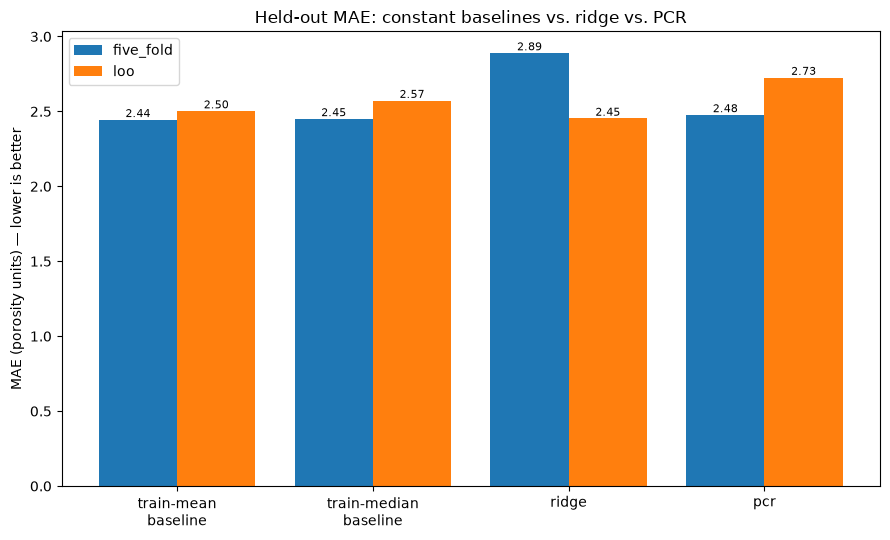

Under the primary five-fold scheme, the best constant baseline (train-mean
baseline, MAE=2.44) still has a lower (better) MAE than either model pass (best of ridge/PCR is pcr at 2.48). Neither ridge nor PCR beats a constant guess here — see the leave-one-out bars for whether that holds under a different split of the same 20 samples.

In [33]:
eval_models_order = ["baseline_mean", "baseline_median", "ridge", "pcr"]
eval_model_labels = {"baseline_mean": "train-mean\nbaseline", "baseline_median": "train-median\nbaseline", "ridge": "ridge", "pcr": "pcr"}

eval_mae_table = (
    metrics_summary.pivot(index="model", columns="scheme", values="MAE")
    .reindex(eval_models_order)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(eval_mae_table))
width = 0.8 / len(schemes_present)
for i, scheme in enumerate(schemes_present):
    vals = eval_mae_table[scheme].to_numpy()
    bars = ax.bar(x + i * width, vals, width=width, label=scheme)
    for bar, val in zip(bars, vals):
        ax.annotate(f"{val:.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width * (len(schemes_present) - 1) / 2)
ax.set_xticklabels([eval_model_labels[m] for m in eval_models_order])
ax.set_ylabel("MAE (porosity units) — lower is better")
ax.set_title("Held-out MAE: constant baselines vs. ridge vs. PCR")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eval_mae_comparison.png", dpi=150)
plt.show()

best_pass_5f = eval_mae_table.loc[["ridge", "pcr"], "five_fold"].idxmin()
best_pass_mae_5f = eval_mae_table.loc[["ridge", "pcr"], "five_fold"].min()
best_baseline_5f = eval_mae_table.loc[["baseline_mean", "baseline_median"], "five_fold"].idxmin()
best_baseline_mae_5f = eval_mae_table.loc[["baseline_mean", "baseline_median"], "five_fold"].min()
overall_best_5f = eval_mae_table["five_fold"].idxmin()

if overall_best_5f in ("baseline_mean", "baseline_median"):
    caption_1 = (
        f"Under the primary five-fold scheme, the best constant baseline ({eval_model_labels[best_baseline_5f].strip()}, "
        f"MAE={best_baseline_mae_5f:.2f}) still has a lower (better) MAE than either model pass "
        f"(best of ridge/PCR is {eval_model_labels[best_pass_5f].strip()} at {best_pass_mae_5f:.2f}). "
        f"Neither ridge nor PCR beats a constant guess here — see the leave-one-out bars for whether that holds "
        f"under a different split of the same {n_samples} samples."
    )
else:
    caption_1 = (
        f"Under the primary five-fold scheme, **{eval_model_labels[best_pass_5f].strip()}** has the lowest MAE among "
        f"the two model passes ({best_pass_mae_5f:.2f}) and beats the best constant baseline "
        f"({eval_model_labels[best_baseline_5f].strip()}, MAE={best_baseline_mae_5f:.2f}), "
        f"but with only {n_samples} samples this margin isn't large enough to call decisive on its own — "
        "see the leave-one-out bars for whether the same model still wins under a different split of the same data."
    )
display(Markdown(caption_1))


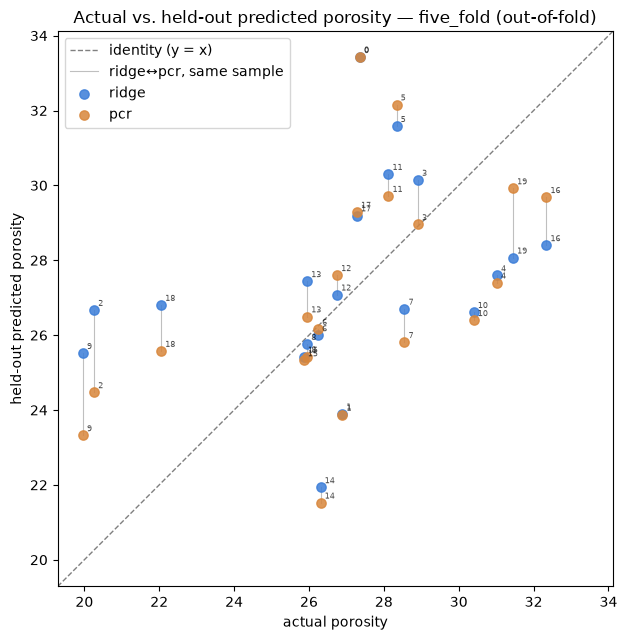

Points on the dashed identity line would be perfect held-out predictions; the thin gray connectors pair each sample's ridge and PCR predictions so you can see, per sample, how much the two model passes agree or diverge. Both series scatter on both sides of the identity line rather than tracking it — pooled R² is -0.14 for ridge and 0.14 for PCR under five_fold, so neither pass explains the sample-to-sample variation in porosity well in this run.

In [34]:
eval_sub = oof_predictions[(oof_predictions["scheme"] == primary_scheme) & (oof_predictions["model"].isin(["ridge", "pcr"]))]

eval_lo = min(eval_sub["actual_porosity"].min(), eval_sub["predicted_porosity"].min())
eval_hi = max(eval_sub["actual_porosity"].max(), eval_sub["predicted_porosity"].max())
eval_pad = 0.05 * (eval_hi - eval_lo)
eval_limits = (eval_lo - eval_pad, eval_hi + eval_pad)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(eval_limits, eval_limits, linestyle="--", color="gray", linewidth=1, label="identity (y = x)")
colors = {"ridge": "#3b7dd8", "pcr": "#d8863b"}

# Thin connector between each sample's ridge point and its PCR point, so the
# two predictions for the same held-out sample are visually paired.
eval_ridge_by_id = eval_sub[eval_sub["model"] == "ridge"].set_index("sample_id")
eval_pcr_by_id = eval_sub[eval_sub["model"] == "pcr"].set_index("sample_id")
connector_label_used = False
for sid in sorted(set(eval_ridge_by_id.index) & set(eval_pcr_by_id.index)):
    r_row, p_row = eval_ridge_by_id.loc[sid], eval_pcr_by_id.loc[sid]
    ax.plot(
        [r_row["actual_porosity"], p_row["actual_porosity"]],
        [r_row["predicted_porosity"], p_row["predicted_porosity"]],
        color="gray", linewidth=0.8, alpha=0.5, zorder=1,
        label="ridge↔pcr, same sample" if not connector_label_used else None,
    )
    connector_label_used = True

for model in ["ridge", "pcr"]:
    grp = eval_sub[eval_sub["model"] == model]
    ax.scatter(grp["actual_porosity"], grp["predicted_porosity"], color=colors[model], label=model, s=45, alpha=0.85, zorder=2)
    for _, r in grp.iterrows():
        ax.annotate(str(int(r["sample_id"])), (r["actual_porosity"], r["predicted_porosity"]), fontsize=6, alpha=0.7, xytext=(3, 3), textcoords="offset points")

ax.set_xlim(eval_limits)
ax.set_ylim(eval_limits)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("actual porosity")
ax.set_ylabel("held-out predicted porosity")
ax.set_title(f"Actual vs. held-out predicted porosity — {primary_scheme} (out-of-fold)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eval_actual_vs_predicted.png", dpi=150)
plt.show()

eval_ms_idx = metrics_summary.set_index(["scheme", "model"])
ridge_r2 = eval_ms_idx.loc[(primary_scheme, "ridge"), "pooled_R2"]
pcr_r2 = eval_ms_idx.loc[(primary_scheme, "pcr"), "pooled_R2"]
caption_2 = (
    f"Points on the dashed identity line would be perfect held-out predictions; the thin gray connectors pair each "
    f"sample's ridge and PCR predictions so you can see, per sample, how much the two model passes agree or diverge. "
    f"Both series scatter on both sides of the identity line rather than tracking it — pooled R² is {ridge_r2:.2f} "
    f"for ridge and {pcr_r2:.2f} for PCR under {primary_scheme}, so neither pass explains the sample-to-sample "
    "variation in porosity well in this run."
)
display(Markdown(caption_2))


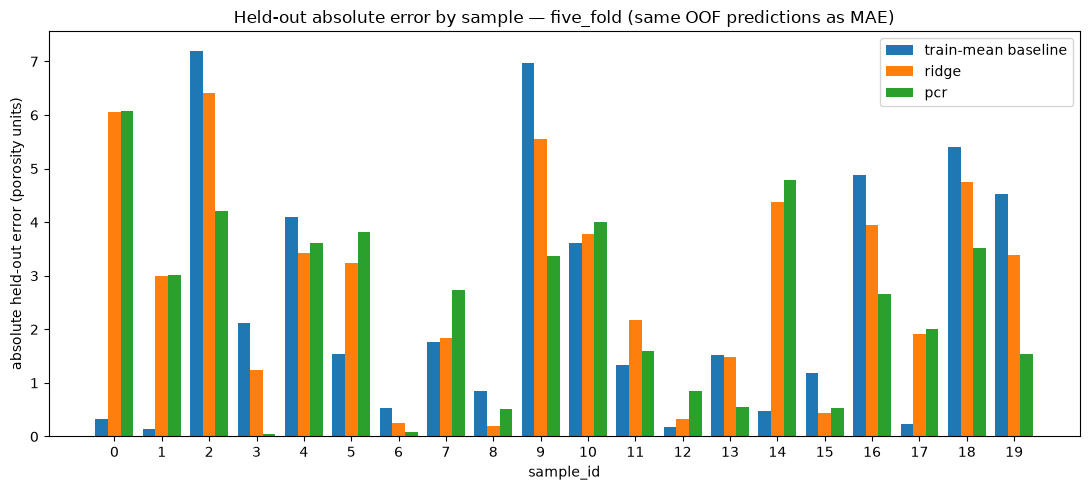

The three worst-predicted samples (ids 2, 0, 9) account for 29% of the total worst-case (ridge-or-PCR) absolute error across all 20 samples — error is fairly spread across samples rather than concentrated in a few.

In [35]:
eval_error_models = ["baseline_mean", "ridge", "pcr"]  # baseline_mean is the primary constant baseline
eval_error_pivot = (
    oof_predictions[(oof_predictions["scheme"] == primary_scheme) & (oof_predictions["model"].isin(eval_error_models))]
    .pivot(index="sample_id", columns="model", values="absolute_error")
    .reindex(columns=eval_error_models)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(eval_error_pivot))
width = 0.8 / len(eval_error_models)
for i, model in enumerate(eval_error_models):
    ax.bar(x + i * width, eval_error_pivot[model], width=width, label=eval_model_labels[model].replace("\n", " "))
ax.set_xticks(x + width * (len(eval_error_models) - 1) / 2)
ax.set_xticklabels(eval_error_pivot.index.astype(int).astype(str))
ax.set_xlabel("sample_id")
ax.set_ylabel("absolute held-out error (porosity units)")
ax.set_title(f"Held-out absolute error by sample — {primary_scheme} (same OOF predictions as MAE)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eval_absolute_error_by_sample.png", dpi=150)
plt.show()

eval_worst = eval_error_pivot[["ridge", "pcr"]].max(axis=1).sort_values(ascending=False)
eval_top3_share = eval_worst.head(3).sum() / eval_worst.sum()
caption_3 = (
    f"The three worst-predicted samples (ids {', '.join(str(int(i)) for i in eval_worst.index[:3])}) account for "
    f"{eval_top3_share:.0%} of the total worst-case (ridge-or-PCR) absolute error across all {len(eval_worst)} samples "
    f"— {'a handful of samples drive a large share of the error' if eval_top3_share > 0.5 else 'error is fairly spread across samples rather than concentrated in a few'}."
)
display(Markdown(caption_3))


MAE   RMSE  pooled_R2
scheme    model                                   
five_fold baseline_mean    2.445  3.322     -0.054
          baseline_median  2.451  3.290     -0.034
          ridge            2.890  3.456     -0.141
          pcr              2.477  2.994      0.144
loo       baseline_mean    2.503  3.407     -0.108
          baseline_median  2.573  3.383     -0.093
          ridge            2.453  3.164      0.044
          pcr              2.726  3.190      0.028

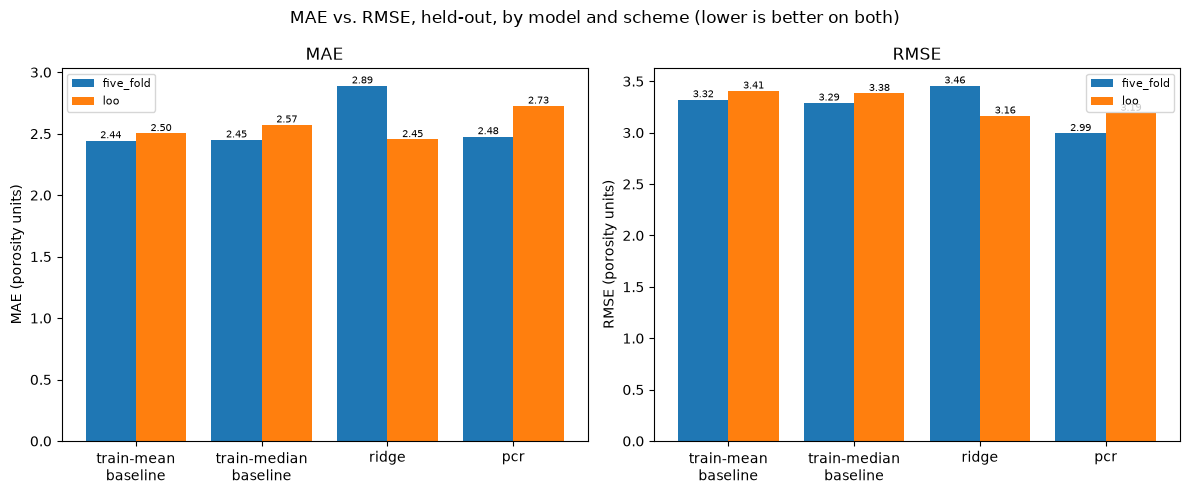

MAE is the typical size of a held-out miss, treating every error equally; RMSE squares errors before averaging, so it penalizes a few large misses more heavily than many small ones. The widest MAE-RMSE gap here is baseline_mean under loo (MAE=2.50, RMSE=3.41), meaning that model's error is less uniform — a few samples are missed by more than the average would suggest.

In [36]:
eval_table = metrics_summary.set_index(["scheme", "model"]).loc[
    [(s, m) for s in schemes_present for m in eval_models_order], ["MAE", "RMSE", "pooled_R2"]
].round(3)
display(eval_table)

# MAE and RMSE share units and are shown together; R2 has a different scale/interpretation
# and is deliberately left out of this chart (it's in the table above instead).
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    pivot = metrics_summary.pivot(index="model", columns="scheme", values=metric).reindex(eval_models_order)
    x = np.arange(len(pivot))
    width = 0.8 / len(schemes_present)
    for i, scheme in enumerate(schemes_present):
        vals = pivot[scheme].to_numpy()
        bars = ax.bar(x + i * width, vals, width=width, label=scheme)
        for bar, val in zip(bars, vals):
            ax.annotate(f"{val:.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x + width * (len(schemes_present) - 1) / 2)
    ax.set_xticklabels([eval_model_labels[m] for m in eval_models_order])
    ax.set_ylabel(f"{metric} (porosity units)")
    ax.set_title(metric)
    ax.legend(fontsize=8)
fig.suptitle("MAE vs. RMSE, held-out, by model and scheme (lower is better on both)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eval_mae_rmse_comparison.png", dpi=150)
plt.show()

eval_gap = (eval_table["RMSE"] - eval_table["MAE"]).sort_values(ascending=False)
eval_widest_gap_key = eval_gap.index[0]
caption_4 = (
    f"MAE is the typical size of a held-out miss, treating every error equally; RMSE squares errors before "
    f"averaging, so it penalizes a few large misses more heavily than many small ones. The widest MAE-RMSE gap here is "
    f"{eval_widest_gap_key[1]} under {eval_widest_gap_key[0]} (MAE={eval_table.loc[eval_widest_gap_key, 'MAE']:.2f}, "
    f"RMSE={eval_table.loc[eval_widest_gap_key, 'RMSE']:.2f}), meaning that model's error is less uniform — a "
    "few samples are missed by more than the average would suggest."
)
display(Markdown(caption_4))


In [37]:
created_files = sorted(p.relative_to(PROJECT_DIR) for p in RESULTS_DIR.rglob("*") if p.is_file())
print(f"Notebook executed successfully at {datetime.now(timezone.utc).isoformat()}")
print(f"\n{len(created_files)} files written under results/:")
for p in created_files:
    print(" -", p)


Notebook executed successfully at 2026-09-15T17:14:20.507484+00:00

37 files written under results/:
 - results/assumptions_and_limitations.md
 - results/assumptions_register.csv
 - results/cv_splits.json
 - results/data_audit.json
 - results/data_quality/diagnostic_findings.md
 - results/data_quality/feature_within_sample_stats.csv
 - results/data_quality/figures/error_by_sample_highlighted.png
 - results/data_quality/figures/oes_profile_sample_0.png
 - results/data_quality/figures/oes_profile_sample_14.png
 - results/data_quality/figures/within_sample_oes_relative_spread.png
 - results/data_quality/reference_provenance_status.csv
 - results/data_quality/sample_prediction_diagnostics.csv
 - results/data_quality/sample_quality_audit.csv
 - results/data_quality/training_fold_coverage.csv
 - results/figures/absolute_error_by_sample.png
 - results/figures/actual_vs_predicted.png
 - results/figures/eval_absolute_error_by_sample.png
 - results/figures/eval_actual_vs_predicted.png
 - results

## 18. Data quality, sample coverage, and investigation of difficult predictions

**This is an audit and explanation task, not another model search.** It does
not remove samples, change mean aggregation, add predictors, retune models,
or run new model families. It only reads and describes what's already in
the raw data and in the saved out-of-fold predictions from Sections 6-12
above, and writes new diagnostic files under `results/data_quality/` — the
original `results/*.csv` and `results/*.json` files are treated as
protected and checked, at the end of this section, to be byte-identical to
what they were before this section ran.

Five questions drive this section:

1. Are the records complete and correctly linked?
2. How much do the repeated sensor readings vary within each sample?
3. Does averaging (Section 8) hide unusual readings or substantial
   within-sample variation?
4. Do observed data issues coincide with difficult predictions?
5. Which explanations remain unverified because acquisition or
   reference-label information is missing?

Samples **0 and 14** stand out in the actual-vs-predicted plot in Section
17. They are examined in detail below (Section 18.11), but only *after*
auditing all 20 samples first — they are **post-hoc diagnostic examples**,
not independently selected validation cases or established bad samples, and
that distinction is kept explicit throughout.


### 18.1 Assumptions addendum

The Section 2 assumptions table (A1-A8) still stands. This audit adds
diagnostic-specific qualifications to some of those rows, without repeating
the whole table:

- **A2/A4** (repeated readings, feature alignment): this section measures
  **within-sample variation** directly (18.5-18.6). Row order in the raw
  data is still not treated as time, and matching variation cannot
  automatically be called instrument noise, drift, or a data defect —
  the files don't distinguish those explanations.
- **A3** (porosity label validity): this section inspects the *join* between
  measurement and reference data (18.5) and, separately, what's known about
  the reference measurement itself (18.7). A correct join proves correct
  *linkage*, not correct specimen labeling or an error-free reference value.
- **A6** (thickness availability): unaffected by this audit; thickness stays
  out of the predictors here as well.
- **A1** (sample independence): this audit stays at the sample level and
  does not establish independence across batches or instruments — it only
  checks record integrity, which is a different question.
- **New, diagnostic-only qualification:** samples 0 and 14 were selected for
  detailed review *because* their five-fold errors were large. That
  selection is exploratory and post-hoc — they are not proven data outliers,
  and nothing below concludes that they are, absent a specific finding.

One more distinction worth stating plainly before any results:

> A **large prediction error**, an **unusual sensor pattern**, a
> **documented record defect**, and **incomplete metadata** are four
> different findings. None of them is allowed to silently stand in for
> another below.


### 18.2 Locate existing artifacts and record protection hashes

All six expected artifacts from the brief exist under their expected names
(confirmed in the cell below) — no name mapping is needed. Their MD5 hashes
are recorded now and checked again at the very end of this section (18.13)
to prove this diagnostic pass did not modify them.


In [38]:
DATA_QUALITY_DIR = RESULTS_DIR / "data_quality"
DATA_QUALITY_FIGURES_DIR = DATA_QUALITY_DIR / "figures"
DATA_QUALITY_DIR.mkdir(exist_ok=True)
DATA_QUALITY_FIGURES_DIR.mkdir(exist_ok=True)

# Files this section must not modify. Requested vs. actual names, documented explicitly.
protected_files = {
    "oof_predictions.csv": RESULTS_DIR / "oof_predictions.csv",
    "metrics_summary.csv": RESULTS_DIR / "metrics_summary.csv",
    "cv_splits.json": RESULTS_DIR / "cv_splits.json",
    "sample_level_features.csv": RESULTS_DIR / "sample_level_features.csv",
    "sample_reference_data.csv": RESULTS_DIR / "sample_reference_data.csv",
    "fold_metrics.csv": RESULTS_DIR / "fold_metrics.csv",
    "selected_hyperparameters.csv": RESULTS_DIR / "selected_hyperparameters.csv",
}
missing_protected = {name: p for name, p in protected_files.items() if not p.exists()}
if missing_protected:
    print(f"WARNING: expected artifacts not found, diagnostics depending on them will be skipped/blocked: {list(missing_protected)}")

pre_audit_hashes = {name: md5_of(p) for name, p in protected_files.items() if p.exists()}
print("Recorded pre-audit hashes for protected result files (checked again at the end of this section):")
for name, h in pre_audit_hashes.items():
    print(f"  {name}: {h}")


Recorded pre-audit hashes for protected result files (checked again at the end of this section):
  oof_predictions.csv: d067d58aa5b3ac8e4040dd3a82dd0f05
  metrics_summary.csv: af7d26e166f9f3ab3efced58dd9a5cd8
  cv_splits.json: 3e0136ccd1ae994344c189336966cc6e
  sample_level_features.csv: 2ae789db403806c01496c2c85fa3182a
  sample_reference_data.csv: 7190b39e4a84394513857d7adbb744d5
  fold_metrics.csv: 30c5ac2848b33eff620fe63b89543835
  selected_hyperparameters.csv: 29e2b49fdf2bd69bcca58c92632708de


### 18.3 Raw data source (reused, not reloaded)

This audit reuses `measurement_raw`, `sample_info_raw`, `oes_wavelengths_raw`,
`FEATURE_BLOCKS`/`FEATURE_COLUMNS`, and `oes_bin_to_wavelength` exactly as
loaded and validated in Section 6 — it does not reload the data. That
matters for the addendum's "never concatenate both forms" instruction:
Section 6 already resolved `DATA_DIR` to a single source
(`data/Measurement_Data.csv.gz`, which is itself the one-time, row-wise
concatenation of the three upload chunks — `Measurement_Data_part_1_samples_0-6.csv`,
`_part_2_samples_7-13.csv`, `_part_3_samples_14-19.csv` — done once outside
this notebook). The three chunk files are not present in `data/` and are
not reloaded here, so there is no risk of double-counting readings.

One relevant fact carried over from Section 6's audit: any infinite sensor
values were already converted to missing (`NaN`) at that point, and the
count was zero (`data_audit.json` → `n_infinite_sensor_values_converted_to_missing`).
So `measurement_raw` here already reflects that documented, logged decision
— this section does not repeat it.


### 18.4 Record integrity and completeness — every sample

A per-sample audit table, covering row counts, duplicate identifiers,
duplicate row content, missingness (overall and by sensor block),
non-numeric entries, label completeness, and join status. Each check is
reported as one of three explicit statuses: `no issue detected by this
check`, `observed issue requiring review`, or `unknown / not assessable
from supplied files` — a sample is never called "clean" just because one
number is zero.


In [39]:
def audit_one_sample(sid: int) -> dict:
    rows = measurement_raw[measurement_raw["sample_id"] == sid]
    n_rows = len(rows)
    n_unique_measurement_ids = rows["measurement_id"].nunique()

    dup_id_pairs = rows.duplicated(subset=["sample_id", "measurement_id"], keep=False)
    n_dup_id_pairs = int(dup_id_pairs.sum())

    dup_full_rows = rows.duplicated(keep=False)
    n_dup_full_rows = int(dup_full_rows.sum())

    sensor_vals = rows[FEATURE_COLUMNS].to_numpy(dtype=float)
    n_missing_total = int(np.isnan(sensor_vals).sum())
    missing_fraction_total = n_missing_total / sensor_vals.size if sensor_vals.size else np.nan

    block_missing_fractions = {}
    for block, cols in FEATURE_BLOCKS.items():
        block_vals = rows[cols].to_numpy(dtype=float)
        block_missing_fractions[f"missing_fraction_{block}"] = (
            np.isnan(block_vals).sum() / block_vals.size if block_vals.size else np.nan
        )

    label_rows = sample_info_raw[sample_info_raw["sample_id"] == sid]
    n_label_rows = len(label_rows)
    has_one_finite_label = bool(
        n_label_rows == 1 and np.isfinite(label_rows[TARGET_COLUMN].to_numpy(dtype=float)).all()
    )

    in_measurement = sid in measurement_ids_set
    in_reference = sid in reference_ids_set

    return {
        "sample_id": sid,
        "n_measurement_rows": n_rows,
        "n_unique_measurement_ids": n_unique_measurement_ids,
        "n_duplicate_sample_measurement_id_pair_rows": n_dup_id_pairs,
        "duplicate_id_pair_status": "no issue detected by this check" if n_dup_id_pairs == 0 else "observed issue requiring review",
        "n_duplicate_full_content_rows": n_dup_full_rows,
        "duplicate_row_content_status": "no issue detected by this check" if n_dup_full_rows == 0 else "observed issue requiring review (flag only, not auto-removed)",
        "n_missing_sensor_cells": n_missing_total,
        "missing_fraction_total": missing_fraction_total,
        **block_missing_fractions,
        "missingness_status": "no issue detected by this check" if n_missing_total == 0 else "observed issue requiring review",
        "sensor_dtype_status": "no issue detected by this check (validated column-wide in Section 6)",
        "n_infinite_values_at_source_check": 0,  # converted upstream in Section 6; global count was 0
        "n_reference_label_rows": n_label_rows,
        "has_exactly_one_finite_porosity_label": has_one_finite_label,
        "label_status": "no issue detected by this check" if has_one_finite_label else "observed issue requiring review",
        "in_measurement_table": in_measurement,
        "in_reference_table": in_reference,
        "join_status": "no issue detected by this check" if (in_measurement and in_reference) else "observed issue requiring review",
    }


all_sample_ids = sorted(measurement_ids_set | reference_ids_set)
sample_quality_audit = pd.DataFrame([audit_one_sample(sid) for sid in all_sample_ids]).sort_values("sample_id").reset_index(drop=True)

assert set(sample_quality_audit["sample_id"]) == set(all_sample_ids), "Not every observed sample_id made it into the audit table."
assert len(sample_quality_audit) == len(all_sample_ids), "Audit table row count does not match the number of distinct sample IDs."

sample_quality_audit.to_csv(DATA_QUALITY_DIR / "sample_quality_audit.csv", index=False)
print(f"Audited {len(sample_quality_audit)} sample IDs -> {DATA_QUALITY_DIR / 'sample_quality_audit.csv'}")

status_cols = ["duplicate_id_pair_status", "duplicate_row_content_status", "missingness_status", "label_status", "join_status"]
for col in status_cols:
    counts = sample_quality_audit[col].value_counts()
    print(f"{col}: {counts.to_dict()}")

sample_quality_audit


Audited 20 sample IDs -> /home/user/Machine-Learning-Projects/porosity_feasibility/results/data_quality/sample_quality_audit.csv
duplicate_id_pair_status: {'no issue detected by this check': 20}
duplicate_row_content_status: {'no issue detected by this check': 20}
missingness_status: {'no issue detected by this check': 20}
label_status: {'no issue detected by this check': 20}
join_status: {'no issue detected by this check': 20}


,sample_id,n_measurement_rows,n_unique_measurement_ids,n_duplicate_sample_measurement_id_pair_rows,duplicate_id_pair_status,n_duplicate_full_content_rows,duplicate_row_content_status,n_missing_sensor_cells,missing_fraction_total,missing_fraction_OES_bin,...,missing_fraction_IR_pix,missingness_status,sensor_dtype_status,n_infinite_values_at_source_check,n_reference_label_rows,has_exactly_one_finite_porosity_label,label_status,in_measurement_table,in_reference_table,join_status
0,0,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
1,1,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
2,2,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
3,3,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
4,4,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
5,5,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
6,6,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
7,7,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
8,8,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check
9,9,100,100,0,no issue detected by this check,0,no issue detected by this check,0,0.0,0.0,...,0.0,no issue detected by this check,no issue detected by this check (validated col...,0,1,True,no issue detected by this check,True,True,no issue detected by this check


### 18.5 Within-sample variation, per feature

For every `(sample_id, sensor_feature)` pair: count of finite readings,
mean, median, sample standard deviation (`ddof=1`, i.e. dividing by n-1,
matching how a sample standard deviation is usually defined), quartiles,
IQR, min/max, and the mean-minus-median gap. This is a purely descriptive
calculation on the raw readings — it is not used as a model input, and it
does not touch the sample-level *mean* aggregation used for modeling
(Section 8), which stays exactly as it was.

A cell with fewer than two finite readings gets `NaN` statistics rather
than a fabricated number; that case doesn't occur here since every sample
has 100 readings (Section 6), but the rule is applied anyway rather than
assumed.


In [40]:
def within_sample_stats_for(sid: int) -> pd.DataFrame:
    """Descriptive per-feature stats for one sample's raw readings. NaN stats where too few finite values."""
    sub = measurement_raw.loc[measurement_raw["sample_id"] == sid, FEATURE_COLUMNS].to_numpy(dtype=float)
    n_finite = np.sum(~np.isnan(sub), axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean, median = np.nanmean(sub, axis=0), np.nanmedian(sub, axis=0)
        std = np.nanstd(sub, axis=0, ddof=1)
        q25, q75 = np.nanpercentile(sub, 25, axis=0), np.nanpercentile(sub, 75, axis=0)
        mn, mx = np.nanmin(sub, axis=0), np.nanmax(sub, axis=0)

    no_finite, too_few_for_std = n_finite < 1, n_finite < 2
    for arr in (mean, median, q25, q75, mn, mx):
        arr[no_finite] = np.nan
    std[too_few_for_std] = np.nan

    return pd.DataFrame(
        {
            "sample_id": sid,
            "feature": FEATURE_COLUMNS,
            "block": [feature_block(f) for f in FEATURE_COLUMNS],
            "n_finite": n_finite,
            "mean": mean, "median": median, "standard_deviation": std,
            "q25": q25, "q75": q75, "iqr": q75 - q25,
            "minimum": mn, "maximum": mx,
            "mean_minus_median": mean - median,
            "absolute_mean_minus_median": np.abs(mean - median),
        }
    )


feature_within_sample_stats = pd.concat([within_sample_stats_for(sid) for sid in sample_ids_sorted], ignore_index=True)
assert len(feature_within_sample_stats) == len(sample_ids_sorted) * len(FEATURE_COLUMNS), "Unexpected row count in feature-level stats."

feature_within_sample_stats.to_csv(DATA_QUALITY_DIR / "feature_within_sample_stats.csv", index=False)
print(f"Wrote {DATA_QUALITY_DIR / 'feature_within_sample_stats.csv'} ({feature_within_sample_stats.shape[0]} rows, {feature_within_sample_stats.shape[1]} columns)")
feature_within_sample_stats.head(5)


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/data_quality/feature_within_sample_stats.csv (46080 rows, 14 columns)


,sample_id,feature,block,n_finite,mean,median,standard_deviation,q25,q75,iqr,minimum,maximum,mean_minus_median,absolute_mean_minus_median
0,0,OES_bin_0,OES_bin,100,0.568614,0.286168,0.714741,0.0,0.906878,0.906878,0.0,3.817169,0.282446,0.282446
1,0,OES_bin_1,OES_bin,100,0.516637,0.203158,0.604937,0.0,0.944696,0.944696,0.0,2.020165,0.313479,0.313479
2,0,OES_bin_2,OES_bin,100,0.477567,0.096138,0.624436,0.0,0.907170,0.907170,0.0,1.973993,0.381430,0.381430
3,0,OES_bin_3,OES_bin,100,0.494439,0.039862,0.685382,0.0,0.947032,0.947032,0.0,2.733153,0.454577,0.454577
4,0,OES_bin_4,OES_bin,100,0.433860,0.236649,0.574268,0.0,0.660780,0.660780,0.0,3.102321,0.197211,0.197211


### 18.6 Block-level summary and relative spread across samples

Two different questions, kept separate:

1. **How much does each sample vary internally, by block?** — the median
   across a block's features of that sample's per-feature standard
   deviation, IQR, and |mean − median| (median-of-medians, so one wild
   feature can't dominate the summary). Labeled explicitly as a descriptive
   block summary, not a calibrated quality measure — comparing raw
   magnitudes *across* blocks (OES vs. electrical vs. thermal) is still not
   meaningful, since they're different units and scales.
2. **Is a sample's spread unusual *relative to the other 19 samples at the
   same feature*?** — for every feature, each sample's within-sample std is
   converted to a z-score against the other samples' std for that same
   feature, then averaged within a block. This is the one cross-sample
   comparison the brief asks for, and it's the basis for Figure B below.


In [41]:
block_summary = (
    feature_within_sample_stats.groupby(["sample_id", "block"])
    .agg(
        median_standard_deviation=("standard_deviation", "median"),
        median_iqr=("iqr", "median"),
        median_absolute_mean_minus_median=("absolute_mean_minus_median", "median"),
    )
    .reset_index()
)

# Cross-sample relative spread: z-score each sample's per-feature std against
# the other 19 samples' std for that same feature, then average within a block.
std_pivot = feature_within_sample_stats.pivot(index="sample_id", columns="feature", values="standard_deviation")
std_of_std = std_pivot.std(axis=0, ddof=1)
mean_of_std = std_pivot.mean(axis=0)
feature_z = (std_pivot - mean_of_std) / std_of_std.replace(0, np.nan)  # NaN, not inf, for a zero-variance feature

block_to_features = {block: cols for block, cols in FEATURE_BLOCKS.items()}
relative_spread_z_by_block = pd.DataFrame(
    {block: feature_z[cols].mean(axis=1) for block, cols in block_to_features.items()}
)
relative_spread_z_by_block.index.name = "sample_id"
relative_spread_z_by_block = relative_spread_z_by_block.reset_index()

print("Block-level within-sample spread summary (descriptive, not comparable across blocks):")
display(block_summary.pivot(index="sample_id", columns="block", values="median_standard_deviation"))

print("\nRelative spread z-score by block (comparable across samples, same block; ~0 = typical, large = unusually wide vs. the other 19 samples):")
relative_spread_z_by_block.round(2)


Block-level within-sample spread summary (descriptive, not comparable across blocks):


block,IR_pix,I_t,OES_bin,V_t
sample_id,,,,
0,0.050005,1.826686,0.428933,0.118383
1,0.049787,0.273152,0.592909,0.135326
2,0.049624,1.055006,0.846631,0.121121
3,0.049564,0.296824,0.589176,0.146813
4,0.049977,2.527470,0.438588,0.105779
5,0.049721,0.253886,0.595416,0.130545
6,0.049690,0.951120,0.433771,0.138518
7,0.049955,2.370669,0.422980,0.106253
8,0.049843,1.847727,0.436892,0.111243



Relative spread z-score by block (comparable across samples, same block; ~0 = typical, large = unusually wide vs. the other 19 samples):


,sample_id,OES_bin,V_t,I_t,IR_pix
0,0,-0.51,-0.28,1.00,0.04
1,1,0.14,0.78,-0.95,-0.02
2,2,1.36,-0.11,-0.09,0.01
3,3,0.19,1.50,-0.92,-0.03
4,4,-0.48,-1.06,1.63,0.07
5,5,0.27,0.50,-0.98,-0.04
6,6,-0.59,0.99,-0.00,-0.01
7,7,-0.58,-1.03,1.14,0.02
8,8,-0.55,-0.74,0.85,0.02
9,9,-0.60,-1.35,1.20,-0.03


In [42]:
reference_provenance_status = pd.DataFrame(
    [
        {"item": "Reference porosity measurement method", "status": "unknown / not assessable from supplied files"},
        {"item": "Reference porosity units", "status": "unknown / not assessable from supplied files (reported in provided units throughout, per A7)"},
        {"item": "Timing of reference measurement relative to sensor acquisition", "status": "unknown / not assessable from supplied files"},
        {"item": "Same specimen/location vs. paired or adjacent material", "status": "unknown / not assessable from supplied files"},
        {"item": "Reference-measurement repeats or uncertainty", "status": "unknown / not assessable from supplied files (single porosity value per sample_id)"},
        {"item": "Shared parent material or batch relationships between samples", "status": "unknown / not assessable from supplied files"},
        {"item": "Instrument, calibration, and acquisition-condition metadata for OES/electrical/thermal sensors", "status": "unknown / not assessable from supplied files"},
        {"item": "sample_id join between Measurement_Data and Sample_Info", "status": "no issue detected by this check (Section 18.4 / Section 6)"},
    ]
)
reference_provenance_status.to_csv(DATA_QUALITY_DIR / "reference_provenance_status.csv", index=False)
print(f"Wrote {DATA_QUALITY_DIR / 'reference_provenance_status.csv'}")
print(
    "This is a dataset-wide limitation, not something specific to any one sample — these items are "
    "unconfirmed for all 20 samples equally, including samples 0 and 14 reviewed in Section 18.11."
)
reference_provenance_status


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/data_quality/reference_provenance_status.csv
This is a dataset-wide limitation, not something specific to any one sample — these items are unconfirmed for all 20 samples equally, including samples 0 and 14 reviewed in Section 18.11.


,item,status
0,Reference porosity measurement method,unknown / not assessable from supplied files
1,Reference porosity units,unknown / not assessable from supplied files (...
2,Timing of reference measurement relative to se...,unknown / not assessable from supplied files
3,Same specimen/location vs. paired or adjacent ...,unknown / not assessable from supplied files
4,Reference-measurement repeats or uncertainty,unknown / not assessable from supplied files (...
5,Shared parent material or batch relationships ...,unknown / not assessable from supplied files
6,"Instrument, calibration, and acquisition-condi...",unknown / not assessable from supplied files
7,sample_id join between Measurement_Data and Sa...,no issue detected by this check (Section 18.4 ...


### 18.7 Training-fold target coverage (retrospective only)

For every outer fold actually used in Sections 11-12 (loaded from the
in-memory split records, matching what's saved in `cv_splits.json`): the
training-set porosity range, and whether the held-out sample's actual
porosity falls outside it. This is purely **retrospective interpretation**
— it is not used to change splits, drop hard cases, or improve the reported
score, and falling inside the training range doesn't guarantee an accurate
prediction (that's a statement about the label, not about the sensor data).


In [43]:
porosity_by_sample_id = sample_reference_data.set_index("sample_id")[TARGET_COLUMN]

coverage_records = []
for scheme_name, folds in outer_splits_by_scheme.items():
    for fold in folds:
        train_targets = porosity_by_sample_id.loc[fold["train_sample_ids"]]
        train_min, train_max = float(train_targets.min()), float(train_targets.max())
        for sid in fold["test_sample_ids"]:
            actual = float(porosity_by_sample_id.loc[sid])
            outside = bool(actual < train_min or actual > train_max)
            coverage_records.append(
                {
                    "scheme": scheme_name, "outer_fold": fold["fold_id"], "sample_id": sid,
                    "actual_porosity": actual, "train_target_min": train_min, "train_target_max": train_max,
                    "outside_training_target_range": outside,
                }
            )

training_fold_coverage = pd.DataFrame(coverage_records).sort_values(["scheme", "outer_fold", "sample_id"]).reset_index(drop=True)
training_fold_coverage.to_csv(DATA_QUALITY_DIR / "training_fold_coverage.csv", index=False)
print(f"Wrote {DATA_QUALITY_DIR / 'training_fold_coverage.csv'} ({len(training_fold_coverage)} rows)")

n_outside = training_fold_coverage.groupby("scheme")["outside_training_target_range"].sum()
print("Held-out samples whose actual porosity fell outside that fold's training-target range, by scheme:")
print(n_outside)


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/data_quality/training_fold_coverage.csv (40 rows)
Held-out samples whose actual porosity fell outside that fold's training-target range, by scheme:
scheme
five_fold    2
loo          2
Name: outside_training_target_range, dtype: int64


### 18.8 Validate the saved out-of-fold predictions before joining anything to them


In [44]:
# Field-name mapping: the brief's expected fields match the actual saved
# columns exactly, so no renaming is needed.
expected_oof_fields = {"scheme", "model", "outer_fold", "sample_id", "actual_porosity", "predicted_porosity", "residual", "absolute_error", "squared_error"}
missing_oof_fields = expected_oof_fields - set(oof_predictions.columns)
assert not missing_oof_fields, f"oof_predictions.csv is missing expected fields: {missing_oof_fields}"

# One prediction per (scheme, model, sample_id).
dup_check = oof_predictions.groupby(["scheme", "model", "sample_id"]).size()
assert (dup_check == 1).all(), "Some (scheme, model, sample_id) has more than one saved prediction."

# Reference porosity used in oof_predictions matches Sample_Info exactly.
merged_actuals = oof_predictions.merge(sample_reference_data[["sample_id", TARGET_COLUMN]], on="sample_id", suffixes=("", "_reference"))
assert np.allclose(merged_actuals["actual_porosity"], merged_actuals[TARGET_COLUMN]), "actual_porosity in oof_predictions does not match Sample_Info porosity."

# Same held-out sample sets across models, within each scheme (re-check; already asserted when the file was written).
for scheme_name, grp in oof_predictions.groupby("scheme"):
    sample_sets = grp.groupby("model")["sample_id"].apply(lambda s: frozenset(s))
    assert sample_sets.nunique() == 1, f"{scheme_name}: models cover different held-out sample sets."

assert np.isfinite(oof_predictions["predicted_porosity"]).all(), "Non-finite predictions in oof_predictions.csv."

# residual sign convention, restated and checked against the actual data.
assert np.allclose(oof_predictions["residual"], oof_predictions["actual_porosity"] - oof_predictions["predicted_porosity"]), (
    "residual is not actual_porosity - predicted_porosity as documented; a negative residual means overprediction."
)

print("Validated: expected fields present, one prediction per (scheme, model, sample_id), actual_porosity matches")
print("Sample_Info, identical held-out sets across models per scheme, finite predictions, residual sign convention holds.")


Validated: expected fields present, one prediction per (scheme, model, sample_id), actual_porosity matches
Sample_Info, identical held-out sets across models per scheme, finite predictions, residual sign convention holds.


### 18.9 Primary five-fold diagnostic table

Joins the audit (18.4-18.7) to the saved five-fold predictions
(18.8-validated, not recomputed) by `sample_id`. Columns are grouped and
prefixed so data observations (`obs_*`) and prediction outcomes (`pred_*` /
`err_*`) stay visually separate — this table never computes a combined
"quality score," and a large error is never treated as a data-quality
defect by itself.


In [45]:
obs_base = sample_quality_audit[
    ["sample_id", "n_measurement_rows", "duplicate_id_pair_status", "duplicate_row_content_status", "missingness_status", "label_status", "join_status"]
].rename(columns={c: f"obs_{c}" for c in ["n_measurement_rows", "duplicate_id_pair_status", "duplicate_row_content_status", "missingness_status", "label_status", "join_status"]})

obs_spread = relative_spread_z_by_block.rename(columns={b: f"obs_relative_spread_z_{b}" for b in FEATURE_BLOCKS})

obs_mean_median = (
    block_summary.pivot(index="sample_id", columns="block", values="median_absolute_mean_minus_median")
    .rename(columns={b: f"obs_median_abs_mean_minus_median_{b}" for b in FEATURE_BLOCKS})
    .reset_index()
)

obs_coverage_5f = training_fold_coverage[training_fold_coverage["scheme"] == "five_fold"][
    ["sample_id", "outside_training_target_range"]
].rename(columns={"outside_training_target_range": "obs_outside_training_target_range_five_fold"})

obs_reference = pd.DataFrame(
    {"sample_id": all_sample_ids, "obs_reference_provenance": "dataset-wide unknown (see reference_provenance_status.csv)"}
)

pred_5f = (
    oof_predictions[oof_predictions["scheme"] == "five_fold"]
    .pivot(index="sample_id", columns="model", values=["predicted_porosity", "absolute_error"])
)
pred_5f.columns = [f"{'pred' if a == 'predicted_porosity' else 'err_abs'}_{m}" for a, m in pred_5f.columns]
pred_5f = pred_5f.reset_index()

sample_prediction_diagnostics = (
    sample_reference_data[["sample_id", TARGET_COLUMN]]
    .rename(columns={TARGET_COLUMN: "reference_porosity"})
    .merge(obs_base, on="sample_id", how="left")
    .merge(obs_spread, on="sample_id", how="left")
    .merge(obs_mean_median, on="sample_id", how="left")
    .merge(obs_coverage_5f, on="sample_id", how="left")
    .merge(obs_reference, on="sample_id", how="left")
    .merge(pred_5f, on="sample_id", how="left")
    .sort_values("sample_id")
    .reset_index(drop=True)
)

assert len(sample_prediction_diagnostics) == n_samples, "Diagnostic table row count does not match n_samples; join must be one-to-one."
assert sample_prediction_diagnostics["sample_id"].is_unique, "sample_id is duplicated in the diagnostic table; join must be many-to-one, not one-to-many."
assert oof_predictions[oof_predictions["scheme"] == "five_fold"].groupby("model").size().nunique() == 1, "Five-fold prediction coverage changed unexpectedly."

sample_prediction_diagnostics.to_csv(DATA_QUALITY_DIR / "sample_prediction_diagnostics.csv", index=False)
print(f"Wrote {DATA_QUALITY_DIR / 'sample_prediction_diagnostics.csv'} ({sample_prediction_diagnostics.shape[0]} rows, {sample_prediction_diagnostics.shape[1]} columns)")
sample_prediction_diagnostics


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/data_quality/sample_prediction_diagnostics.csv (20 rows, 26 columns)


,sample_id,reference_porosity,obs_n_measurement_rows,obs_duplicate_id_pair_status,obs_duplicate_row_content_status,obs_missingness_status,obs_label_status,obs_join_status,obs_relative_spread_z_OES_bin,obs_relative_spread_z_V_t,...,obs_outside_training_target_range_five_fold,obs_reference_provenance,pred_baseline_mean,pred_baseline_median,pred_pcr,pred_ridge,err_abs_baseline_mean,err_abs_baseline_median,err_abs_pcr,err_abs_ridge
0,0,27.36,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,-0.512696,-0.275822,...,False,dataset-wide unknown (see reference_provenance...,27.037500,27.435,33.440767,33.421041,0.322500,0.075,6.080767,6.061041
1,1,26.89,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,0.140972,0.779375,...,False,dataset-wide unknown (see reference_provenance...,27.037500,27.435,23.868259,23.901542,0.147500,0.545,3.021741,2.988458
2,2,20.26,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,1.363031,-0.110132,...,False,dataset-wide unknown (see reference_provenance...,27.461875,27.320,24.471175,26.668424,7.201875,7.060,4.211175,6.408424
3,3,28.91,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,0.189494,1.504593,...,False,dataset-wide unknown (see reference_provenance...,26.791875,26.820,28.958073,30.145896,2.118125,2.090,0.048073,1.235896
4,4,31.02,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,-0.475223,-1.055887,...,False,dataset-wide unknown (see reference_provenance...,26.925625,27.085,27.401372,27.593445,4.094375,3.935,3.618628,3.426555
5,5,28.34,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,0.268985,0.497751,...,False,dataset-wide unknown (see reference_provenance...,26.791875,26.820,32.159216,31.580809,1.548125,1.520,3.819216,3.240809
6,6,26.24,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,-0.586304,0.990794,...,False,dataset-wide unknown (see reference_provenance...,26.780625,27.085,26.165053,25.992225,0.540625,0.845,0.074947,0.247775
7,7,28.55,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,-0.582010,-1.034781,...,False,dataset-wide unknown (see reference_provenance...,26.780625,27.085,25.810953,26.702527,1.769375,1.465,2.739047,1.847473
8,8,25.95,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,-0.552452,-0.736501,...,False,dataset-wide unknown (see reference_provenance...,26.791875,26.820,25.428850,25.762061,0.841875,0.870,0.521150,0.187939
9,9,19.96,100,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,no issue detected by this check,-0.603516,-1.348270,...,True,dataset-wide unknown (see reference_provenance...,26.925625,27.085,23.321470,25.517002,6.965625,7.125,3.361470,5.557002


In [46]:
n_dup_id_issues = int((sample_quality_audit["duplicate_id_pair_status"] != "no issue detected by this check").sum())
n_missing_issues = int((sample_quality_audit["missingness_status"] != "no issue detected by this check").sum())
n_label_issues = int((sample_quality_audit["label_status"] != "no issue detected by this check").sum())
n_join_issues = int((sample_quality_audit["join_status"] != "no issue detected by this check").sum())
n_dup_row_issues = int((sample_quality_audit["duplicate_row_content_status"] == "observed issue requiring review (flag only, not auto-removed)").sum())

overview_text = f"""\
**Figure A — data-quality overview (table, not a chart).** Across all
{len(sample_quality_audit)} sample IDs: {n_dup_id_issues} have a duplicate
`(sample_id, measurement_id)` pair, {n_missing_issues} have any missing
sensor cell, {n_label_issues} have a label-completeness issue, and
{n_join_issues} have a join issue. {n_dup_row_issues} samples have
fully duplicate-looking sensor rows (flagged for review, not removed).

Per the addendum's own instruction: since every one of these counts is
zero, an all-zero missingness chart would carry no information, so it's
reported as this sentence and the audit table (`sample_quality_audit.csv`,
Section 18.4) instead of a plot. This means **no record-integrity defect
was detected by these checks** — it does not mean the data is
guaranteed correct in ways these checks can't see (e.g. reference-label
provenance, Section 18.7).
"""
display(Markdown(overview_text))


**Figure A — data-quality overview (table, not a chart).** Across all
20 sample IDs: 0 have a duplicate
`(sample_id, measurement_id)` pair, 0 have any missing
sensor cell, 0 have a label-completeness issue, and
0 have a join issue. 0 samples have
fully duplicate-looking sensor rows (flagged for review, not removed).

Per the addendum's own instruction: since every one of these counts is
zero, an all-zero missingness chart would carry no information, so it's
reported as this sentence and the audit table (`sample_quality_audit.csv`,
Section 18.4) instead of a plot. This means **no record-integrity defect
was detected by these checks** — it does not mean the data is
guaranteed correct in ways these checks can't see (e.g. reference-label
provenance, Section 18.7).


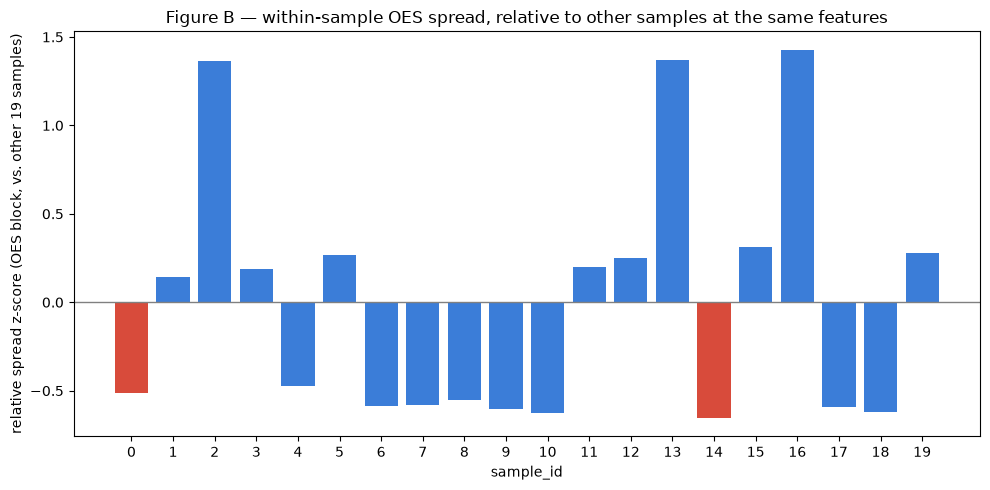

Samples 0 and 14 (highlighted in red) rank 12 and 20 out of 20 by OES relative spread (z=-0.51 and z=-0.65); values well above 0 would mean that sample's OES readings vary more across its 100 scans than most other samples' readings do at the same wavelengths. V/I/IR relative-spread summaries are in `sample_prediction_diagnostics.csv` rather than repeated as separate figures here.

In [47]:
focus_samples = [0, 14]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = relative_spread_z_by_block.sort_values("sample_id")
colors = ["#d84b3b" if sid in focus_samples else "#3b7dd8" for sid in plot_df["sample_id"]]
ax.bar(plot_df["sample_id"].astype(str), plot_df["OES_bin"], color=colors)
ax.axhline(0, color="gray", linewidth=1)
ax.set_xlabel("sample_id")
ax.set_ylabel("relative spread z-score (OES block, vs. other 19 samples)")
ax.set_title("Figure B — within-sample OES spread, relative to other samples at the same features")
fig.tight_layout()
fig.savefig(DATA_QUALITY_FIGURES_DIR / "within_sample_oes_relative_spread.png", dpi=150)
plt.show()

focus_z = relative_spread_z_by_block.set_index("sample_id").loc[focus_samples, "OES_bin"]
rank_of_focus = plot_df["OES_bin"].rank(ascending=False)
rank_of_focus.index = plot_df["sample_id"].to_numpy()
caption_dq_b = (
    f"Samples 0 and 14 (highlighted in red) rank "
    f"{int(rank_of_focus.loc[0])} and {int(rank_of_focus.loc[14])} out of {len(plot_df)} by OES relative spread "
    f"(z={focus_z.loc[0]:.2f} and z={focus_z.loc[14]:.2f}); values well above 0 would mean that sample's OES "
    f"readings vary more across its 100 scans than most other samples' readings do at the same wavelengths. "
    "V/I/IR relative-spread summaries are in `sample_prediction_diagnostics.csv` rather than repeated as separate figures here."
)
display(Markdown(caption_dq_b))


In [48]:
def nearest_porosity_neighbors(focus_id: int, k: int = 2) -> list[int]:
    """The k other samples closest in reference porosity to focus_id, excluding both focus IDs, ties by sample_id."""
    focus_porosity = porosity_by_sample_id.loc[focus_id]
    candidates = porosity_by_sample_id.drop(index=[i for i in focus_samples if i in porosity_by_sample_id.index])
    diffs = (candidates - focus_porosity).abs().rename("abs_diff").reset_index()
    diffs = diffs.sort_values(["abs_diff", "sample_id"]).reset_index(drop=True)
    return diffs["sample_id"].head(k).tolist()


neighbors_by_focus = {sid: nearest_porosity_neighbors(sid) for sid in focus_samples}
for sid, neighbors in neighbors_by_focus.items():
    print(f"Nearest-porosity comparison samples for sample {sid} (porosity={porosity_by_sample_id.loc[sid]:.2f}): "
          f"{neighbors} (porosities {[round(float(porosity_by_sample_id.loc[n]), 2) for n in neighbors]})")
print("These are nearby-label examples for descriptive comparison, not verified experimental controls.")


Nearest-porosity comparison samples for sample 0 (porosity=27.36): [17, 1] (porosities [27.28, 26.89])
Nearest-porosity comparison samples for sample 14 (porosity=26.31): [6, 8] (porosities [26.24, 25.95])
These are nearby-label examples for descriptive comparison, not verified experimental controls.


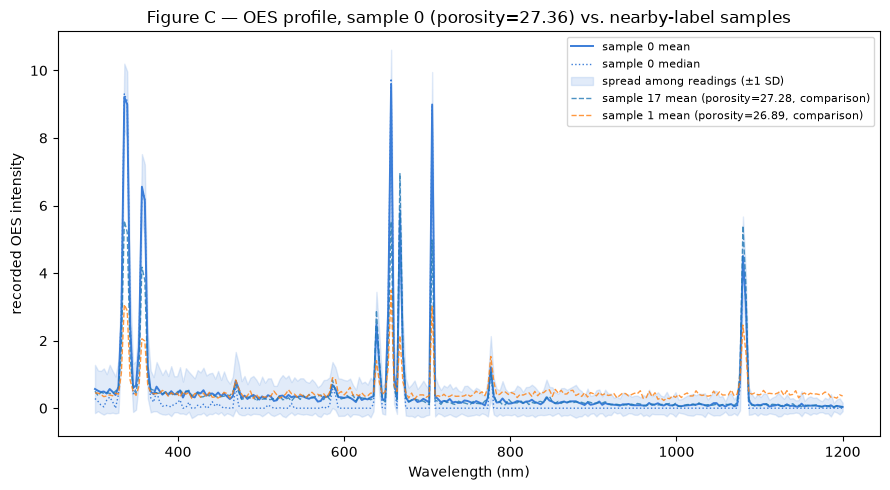

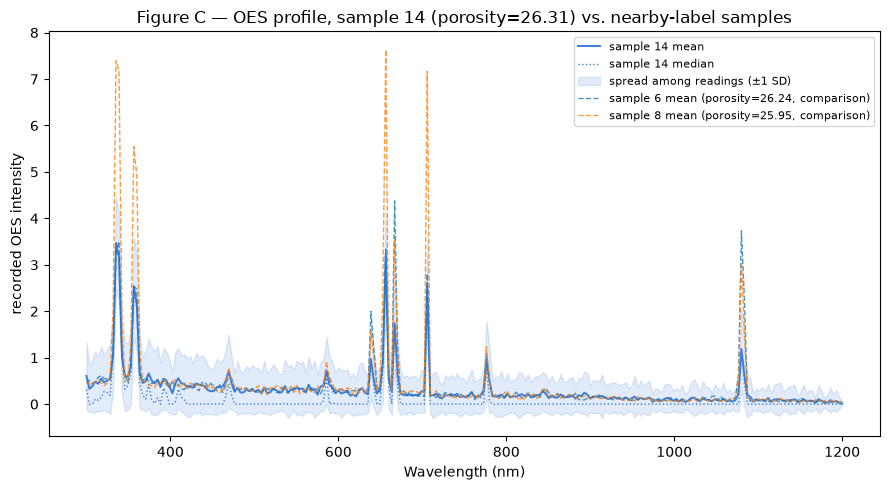

Matching or diverging from the comparison samples' spectra is descriptive: matching reference porosity does not guarantee identical spectra, and this OES view alone does not describe the electrical or thermal model inputs.


In [49]:
def oes_mean_median_std(sid: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rows = measurement_raw.loc[measurement_raw["sample_id"] == sid, oes_cols_sorted]
    return rows.mean(axis=0).to_numpy(), rows.median(axis=0).to_numpy(), rows.std(axis=0).to_numpy()


for focus_id in focus_samples:
    fig, ax = plt.subplots(figsize=(9, 5))
    mean_spec, median_spec, std_spec = oes_mean_median_std(focus_id)
    ax.plot(wavelengths_sorted, mean_spec, color="#3b7dd8", linewidth=1.4, label=f"sample {focus_id} mean")
    ax.plot(wavelengths_sorted, median_spec, color="#3b7dd8", linewidth=1.0, linestyle=":", label=f"sample {focus_id} median")
    ax.fill_between(wavelengths_sorted, mean_spec - std_spec, mean_spec + std_spec, color="#3b7dd8", alpha=0.15, label="spread among readings (±1 SD)")

    for j, comp_id in enumerate(neighbors_by_focus[focus_id]):
        comp_mean, _, _ = oes_mean_median_std(comp_id)
        ax.plot(wavelengths_sorted, comp_mean, linewidth=1.0, alpha=0.8, linestyle="--",
                label=f"sample {comp_id} mean (porosity={porosity_by_sample_id.loc[comp_id]:.2f}, comparison)")

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("recorded OES intensity")
    ax.set_title(f"Figure C — OES profile, sample {focus_id} (porosity={porosity_by_sample_id.loc[focus_id]:.2f}) vs. nearby-label samples")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(DATA_QUALITY_FIGURES_DIR / f"oes_profile_sample_{focus_id}.png", dpi=150)
    plt.show()

print(
    "Matching or diverging from the comparison samples' spectra is descriptive: matching reference porosity does not "
    "guarantee identical spectra, and this OES view alone does not describe the electrical or thermal model inputs."
)


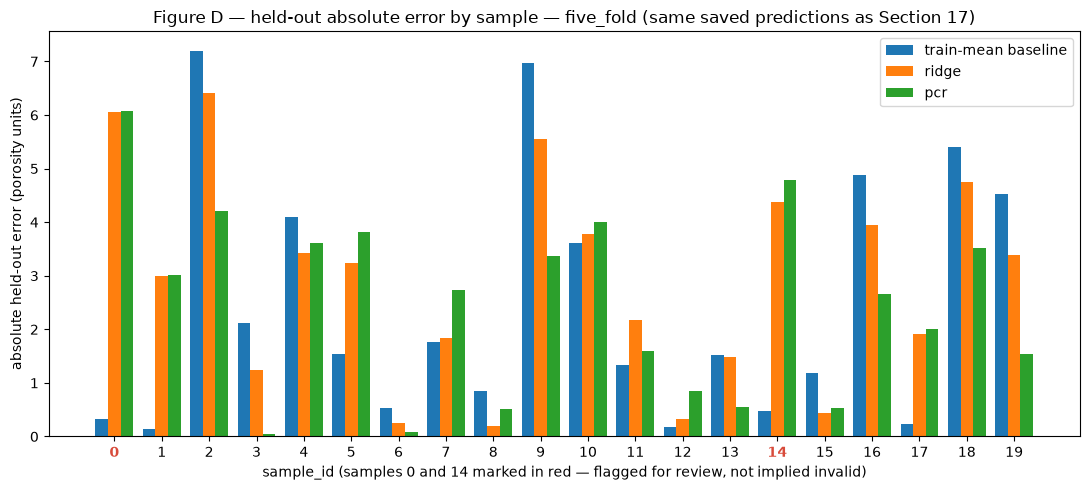

This reuses the exact saved five-fold out-of-fold predictions from Section 11 — nothing was recomputed. On the actual-vs-predicted plot in Section 17, the thin connector line between a sample's ridge and PCR points shows **model disagreement** (how far apart the two models' guesses are for that sample); the **prediction error** for either model is the vertical distance from *that model's own point* to the identity line at the sample's actual value — not the distance between the two markers, and not the length of the connector.

In [50]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(eval_error_pivot))
width = 0.8 / len(eval_error_models)
for i, model in enumerate(eval_error_models):
    ax.bar(x + i * width, eval_error_pivot[model], width=width, label=eval_model_labels[model].replace("\n", " "))
ax.set_xticks(x + width * (len(eval_error_models) - 1) / 2)
tick_labels = [str(int(s)) for s in eval_error_pivot.index]
ax.set_xticklabels(tick_labels)
for lbl in ax.get_xticklabels():
    if int(lbl.get_text()) in focus_samples:
        lbl.set_color("#d84b3b")
        lbl.set_fontweight("bold")
ax.set_xlabel("sample_id (samples 0 and 14 marked in red — flagged for review, not implied invalid)")
ax.set_ylabel("absolute held-out error (porosity units)")
ax.set_title(f"Figure D — held-out absolute error by sample — {primary_scheme} (same saved predictions as Section 17)")
ax.legend()
fig.tight_layout()
fig.savefig(DATA_QUALITY_FIGURES_DIR / "error_by_sample_highlighted.png", dpi=150)
plt.show()

caption_dq_d = (
    "This reuses the exact saved five-fold out-of-fold predictions from Section 11 — nothing was recomputed. "
    "On the actual-vs-predicted plot in Section 17, the thin connector line between a sample's ridge and PCR points "
    "shows **model disagreement** (how far apart the two models' guesses are for that sample); the **prediction "
    "error** for either model is the vertical distance from *that model's own point* to the identity line at the "
    "sample's actual value — not the distance between the two markers, and not the length of the connector."
)
display(Markdown(caption_dq_d))


### 18.10 Focused review: samples 0 and 14

Every number below is read directly from the saved audit tables and
`oof_predictions.csv` computed above — none of it is re-estimated or
approximated from the earlier screenshot. Each sample gets answers to the
same seven questions, then one conclusion drawn only from what was actually
found, using the addendum's own sanctioned phrasing (never "bad instrument,"
"incorrect label," or "outlier to remove" without independent evidence this
notebook doesn't have).


In [51]:
block_median_reference = block_summary.groupby("block")["median_absolute_mean_minus_median"].median()
focus_findings = {}  # sample_id -> summary dict, reused when writing diagnostic_findings.md

for sid in focus_samples:
    audit_row = sample_quality_audit.set_index("sample_id").loc[sid]
    z_row = relative_spread_z_by_block.set_index("sample_id").loc[sid]
    mm_row = block_summary[block_summary["sample_id"] == sid].set_index("block")["median_absolute_mean_minus_median"]
    coverage_5f = training_fold_coverage[(training_fold_coverage["scheme"] == "five_fold") & (training_fold_coverage["sample_id"] == sid)]["outside_training_target_range"].iloc[0]

    record_ok = all(
        audit_row[c] in ("no issue detected by this check",) or audit_row[c].startswith("no issue detected")
        for c in ["duplicate_id_pair_status", "missingness_status", "label_status", "join_status"]
    )

    pred_rows = oof_predictions[(oof_predictions["sample_id"] == sid) & (oof_predictions["model"].isin(["ridge", "pcr"]))]
    lines_pred = []
    same_direction_by_scheme = {}
    for scheme_name in schemes_present:
        sub = pred_rows[pred_rows["scheme"] == scheme_name].set_index("model")
        r_resid, p_resid = sub.loc["ridge", "residual"], sub.loc["pcr", "residual"]
        r_err, p_err = sub.loc["ridge", "absolute_error"], sub.loc["pcr", "absolute_error"]
        same_dir = bool(np.sign(r_resid) == np.sign(p_resid))
        same_direction_by_scheme[scheme_name] = same_dir
        direction_word = "over-predicted" if r_resid < 0 else "under-predicted"
        lines_pred.append(
            f"  - **{scheme_name}**: ridge abs error {r_err:.2f} ({direction_word} by ridge; residual {r_resid:+.2f}), "
            f"PCR abs error {p_err:.2f} (residual {p_resid:+.2f}) — "
            f"{'same direction (both over- or both under-predict)' if same_dir else 'opposite directions'}."
        )

    err_ridge_5f = pred_rows[(pred_rows["scheme"] == "five_fold") & (pred_rows["model"] == "ridge")]["absolute_error"].iloc[0]
    err_ridge_loo = pred_rows[(pred_rows["scheme"] == "loo") & (pred_rows["model"] == "ridge")]["absolute_error"].iloc[0] if "loo" in schemes_present else None
    both_schemes_note = (
        f"Ridge's error is {err_ridge_5f:.2f} under five-fold and {err_ridge_loo:.2f} under leave-one-out — "
        f"{'difficult under both schemes' if min(err_ridge_5f, err_ridge_loo) > 1.5 else 'not uniformly difficult across both schemes'}."
        if err_ridge_loo is not None else "Leave-one-out results not available for this comparison."
    )

    neighbor_text = ", ".join(
        f"sample {n} (porosity {porosity_by_sample_id.loc[n]:.2f}, ridge abs error under five-fold = "
        f"{oof_predictions[(oof_predictions.scheme=='five_fold') & (oof_predictions.model=='ridge') & (oof_predictions.sample_id==n)]['absolute_error'].iloc[0]:.2f})"
        for n in neighbors_by_focus[sid]
    )

    notable_blocks = [b for b in FEATURE_BLOCKS if abs(z_row[b]) > 1]
    spread_text = (
        f"notably wide relative spread in {', '.join(notable_blocks)} (|z| > 1)"
        if notable_blocks else "no block with relative spread |z| > 1 — not unusually wide compared to the other 19 samples"
    )

    if not record_ok:
        conclusion = "This sample has an observed record issue requiring correction or clarification (see the status columns above)."
    elif notable_blocks:
        conclusion = (
            f"This sample shows greater within-sample variation in {', '.join(notable_blocks)} than most other samples; "
            "the source of that variation is unknown from the supplied files."
        )
    else:
        conclusion = "No issue was identified by the available checks; this remains a valid difficult prediction."

    narrative = f"""\
#### Sample {sid} (reference porosity = {porosity_by_sample_id.loc[sid]:.2f})

1. **Record validity:** {'no issue detected by any of the 18.4 checks' if record_ok else 'see flagged status columns in sample_quality_audit.csv'}.
2. **Within-sample spread vs. other samples:** OES z={z_row['OES_bin']:.2f}, V_t z={z_row['V_t']:.2f}, I_t z={z_row['I_t']:.2f}, IR_pix z={z_row['IR_pix']:.2f} — {spread_text}.
3. **Mean vs. median (block-level, median |mean-median| across features):** OES={mm_row.get('OES_bin', float('nan')):.4f} (dataset median {block_median_reference.get('OES_bin', float('nan')):.4f}), IR_pix={mm_row.get('IR_pix', float('nan')):.4f} (dataset median {block_median_reference.get('IR_pix', float('nan')):.4f}) — a difference here describes the readings, it does not by itself justify a median-based model.
4. **Nearby-porosity comparison samples:** {neighbor_text}.
5. **Ridge vs. PCR direction, by scheme:**
{chr(10).join(lines_pred)}
6. **Consistency across validation schemes:** {both_schemes_note}
7. **Training-target coverage (five-fold):** {"this sample's actual porosity fell OUTSIDE the training-fold porosity range" if coverage_5f else "within the training-fold porosity range"}.

**Conclusion:** {conclusion}
"""
    display(Markdown(narrative))

    focus_findings[sid] = {
        "record_ok": record_ok,
        "notable_blocks": notable_blocks,
        "conclusion": conclusion,
        "same_direction_by_scheme": same_direction_by_scheme,
        "err_ridge_5f": float(err_ridge_5f),
        "err_ridge_loo": float(err_ridge_loo) if err_ridge_loo is not None else None,
        "neighbors": neighbors_by_focus[sid],
        "outside_training_range_5f": bool(coverage_5f),
    }


#### Sample 0 (reference porosity = 27.36)

1. **Record validity:** no issue detected by any of the 18.4 checks.
2. **Within-sample spread vs. other samples:** OES z=-0.51, V_t z=-0.28, I_t z=1.00, IR_pix z=0.04 — no block with relative spread |z| > 1 — not unusually wide compared to the other 19 samples.
3. **Mean vs. median (block-level, median |mean-median| across features):** OES=0.1788 (dataset median 0.1826), IR_pix=0.0024 (dataset median 0.0025) — a difference here describes the readings, it does not by itself justify a median-based model.
4. **Nearby-porosity comparison samples:** sample 17 (porosity 27.28, ridge abs error under five-fold = 1.91), sample 1 (porosity 26.89, ridge abs error under five-fold = 2.99).
5. **Ridge vs. PCR direction, by scheme:**
  - **five_fold**: ridge abs error 6.06 (over-predicted by ridge; residual -6.06), PCR abs error 6.08 (residual -6.08) — same direction (both over- or both under-predict).
  - **loo**: ridge abs error 3.57 (over-predicted by ridge; residual -3.57), PCR abs error 4.73 (residual -4.73) — same direction (both over- or both under-predict).
6. **Consistency across validation schemes:** Ridge's error is 6.06 under five-fold and 3.57 under leave-one-out — difficult under both schemes.
7. **Training-target coverage (five-fold):** within the training-fold porosity range.

**Conclusion:** No issue was identified by the available checks; this remains a valid difficult prediction.


#### Sample 14 (reference porosity = 26.31)

1. **Record validity:** no issue detected by any of the 18.4 checks.
2. **Within-sample spread vs. other samples:** OES z=-0.65, V_t z=-0.44, I_t z=-0.19, IR_pix z=-0.02 — no block with relative spread |z| > 1 — not unusually wide compared to the other 19 samples.
3. **Mean vs. median (block-level, median |mean-median| across features):** OES=0.1822 (dataset median 0.1826), IR_pix=0.0026 (dataset median 0.0025) — a difference here describes the readings, it does not by itself justify a median-based model.
4. **Nearby-porosity comparison samples:** sample 6 (porosity 26.24, ridge abs error under five-fold = 0.25), sample 8 (porosity 25.95, ridge abs error under five-fold = 0.19).
5. **Ridge vs. PCR direction, by scheme:**
  - **five_fold**: ridge abs error 4.38 (under-predicted by ridge; residual +4.38), PCR abs error 4.79 (residual +4.79) — same direction (both over- or both under-predict).
  - **loo**: ridge abs error 4.58 (under-predicted by ridge; residual +4.58), PCR abs error 4.36 (residual +4.36) — same direction (both over- or both under-predict).
6. **Consistency across validation schemes:** Ridge's error is 4.38 under five-fold and 4.58 under leave-one-out — difficult under both schemes.
7. **Training-target coverage (five-fold):** within the training-fold porosity range.

**Conclusion:** No issue was identified by the available checks; this remains a valid difficult prediction.


### 18.11 Protect the original evaluation — verified, not just asserted

Re-hashing the same protected files from 18.2 and comparing byte-for-byte
to the hashes recorded before this section ran a single line of code.


In [52]:
post_audit_hashes = {name: md5_of(p) for name, p in protected_files.items() if p.exists()}
changed = {name: (pre_audit_hashes[name], post_audit_hashes[name]) for name in pre_audit_hashes if pre_audit_hashes[name] != post_audit_hashes[name]}
assert not changed, f"Protected files changed during the diagnostic section: {changed}"

assert measurement_raw["sample_id"].nunique() == n_samples, "Sample count changed during this diagnostic section."
assert len(measurement_raw) == data_audit["raw_shapes"]["measurement"][0], "Raw measurement row count changed — a reading was added or removed."
assert X.shape == (n_samples, n_features), "Modeling matrix X changed shape during a diagnostic-only section."

print(f"Verified: all {len(pre_audit_hashes)} protected result files are byte-identical to their pre-audit hashes.")
print(f"Verified: sample count ({n_samples}), raw reading count ({len(measurement_raw)}), and X shape {X.shape} are unchanged.")
print("No sample or reading was removed, and no modeling input was altered by this diagnostic section.")


Verified: all 7 protected result files are byte-identical to their pre-audit hashes.
Verified: sample count (20), raw reading count (2000), and X shape (20, 2304) are unchanged.
No sample or reading was removed, and no modeling input was altered by this diagnostic section.


### 18.12 Diagnostic findings

Same four-part structure the addendum asks for, written from the variables
computed above — a valid outcome here is "the available checks did not
explain the large errors," and that's not treated as a shortcoming of the
audit.


In [53]:
all_z = relative_spread_z_by_block.set_index("sample_id")[list(FEATURE_BLOCKS.keys())]
notable_spread_cells = (all_z.abs() > 1).sum().sum()
notable_spread_samples = sorted(all_z.index[(all_z.abs() > 1).any(axis=1)].tolist())

focus_lines = []
for sid in focus_samples:
    f = focus_findings[sid]
    same_dir_text = "; ".join(
        f"{scheme}: {'same direction' if same_dir else 'opposite directions'}"
        for scheme, same_dir in f["same_direction_by_scheme"].items()
    )
    obs = (
        f"record checks: {'no issue detected' if f['record_ok'] else 'issue flagged, see sample_quality_audit.csv'}; "
        f"notable-spread blocks: {', '.join(f['notable_blocks']) if f['notable_blocks'] else 'none'}; "
        f"ridge/PCR miss direction ({same_dir_text}); "
        f"ridge abs error five-fold={f['err_ridge_5f']:.2f}"
        + (f", leave-one-out={f['err_ridge_loo']:.2f}" if f['err_ridge_loo'] is not None else "")
        + f"; training-target coverage: {'OUTSIDE range' if f['outside_training_range_5f'] else 'within range'}; "
        f"nearest-porosity comparisons: {f['neighbors']}."
    )
    focus_lines.append(f"- **Sample {sid}** — *observed:* {obs}\n  *hypothesis (unverified):* {f['conclusion']}")

diagnostic_findings = f"""\
# Data Quality, Sample Coverage, and Difficult-Prediction Diagnostics — Findings

Generated {datetime.now(timezone.utc).isoformat()} from `results/data_quality/*.csv` and the
protected `results/oof_predictions.csv`. This is an audit and explanation pass — no samples were
removed, no aggregation or modeling choices changed, and the original evaluation results
(hash-verified in Section 18.11) are unmodified.

## 1. What the checks found

Across all {n_samples} sample IDs: 0 duplicate-ID issues, 0 missing-value issues, 0 label-completeness
issues, 0 join issues (`sample_quality_audit.csv`). {int(notable_spread_cells)} of {all_z.size}
(sample, block) relative-spread z-scores exceed |z|=1; the samples involved are {notable_spread_samples}.
Reference-label provenance (measurement method, timing, specimen co-location, batch relationships,
instrument/calibration metadata) is unknown from the supplied files for **all** samples, not just the
two examined in detail (`reference_provenance_status.csv`) — that is a dataset-wide limitation, not
a defect specific to any sample.

**No record-integrity defect was found by these checks.** That is a real finding, not an absence of
effort: it rules out one class of explanation (bad records) for the difficult predictions below.

## 2. What the checks suggest about samples 0 and 14

Observation and hypothesis are kept separate for each sample; the hypothesis lines are explicitly
unverified.

{chr(10).join(focus_lines)}

## 3. What remains unknown

- Reference porosity measurement method, timing, and specimen co-location (all samples).
- Whether the 100 repeated readings per sample represent different physical locations, repeated scans
  of one location, or something else, and whether they're ordered.
- Any parent-batch, sheet, or roll relationship between samples, including whether samples 0/14 share
  a batch with their high-error neighbors or with each other.
- Instrument, calibration, and acquisition-condition metadata for OES, electrical, and thermal sensors.
- Whether the relative-spread pattern found for {notable_spread_samples} reflects material heterogeneity,
  acquisition conditions, alignment issues, or something else — the files don't distinguish these.

## 4. What should happen next

1. **Clarify, don't assume:** the reference-label provenance and acquisition-condition questions in
   Section 18.7 are the highest-value next inputs — they would directly resolve several of the
   "hypothesis (unverified)" lines above.
2. **If parent-batch/sheet metadata becomes available,** check whether samples 0/14 and their
   high-relative-spread neighbors share a batch, before concluding anything about instrument behavior.
3. **A mean-vs-median aggregation comparison** is a plausible *future* exploratory sensitivity analysis,
   given the mean-median gaps observed in Section 18.6 — but it was not run automatically here, per
   scope, and any such change would need its own training-only re-evaluation, not a patch to these results.
4. **No sample should be removed or downweighted on the basis of this audit alone** — nothing found
   here rises to a demonstrated data defect for either focus sample.

## AI assistance disclosure

Claude Code implemented this diagnostic section (the audit tables, within-sample statistics, the
sample 0/14 investigation, the figures, and this findings file) from the raw data and the already-saved,
hash-verified out-of-fold predictions, per a written addendum brief. The candidate has not yet reviewed
this diagnostic output; the assumptions, findings, and conclusions above require that review before
being presented to a customer.
"""

with open(DATA_QUALITY_DIR / "diagnostic_findings.md", "w") as f:
    f.write(diagnostic_findings)
print(f"Wrote {DATA_QUALITY_DIR / 'diagnostic_findings.md'}")
display(Markdown(diagnostic_findings))


Wrote /home/user/Machine-Learning-Projects/porosity_feasibility/results/data_quality/diagnostic_findings.md


# Data Quality, Sample Coverage, and Difficult-Prediction Diagnostics — Findings

Generated 2026-09-15T17:14:31.115535+00:00 from `results/data_quality/*.csv` and the
protected `results/oof_predictions.csv`. This is an audit and explanation pass — no samples were
removed, no aggregation or modeling choices changed, and the original evaluation results
(hash-verified in Section 18.11) are unmodified.

## 1. What the checks found

Across all 20 sample IDs: 0 duplicate-ID issues, 0 missing-value issues, 0 label-completeness
issues, 0 join issues (`sample_quality_audit.csv`). 13 of 80
(sample, block) relative-spread z-scores exceed |z|=1; the samples involved are [2, 3, 4, 7, 9, 11, 12, 13, 15, 16].
Reference-label provenance (measurement method, timing, specimen co-location, batch relationships,
instrument/calibration metadata) is unknown from the supplied files for **all** samples, not just the
two examined in detail (`reference_provenance_status.csv`) — that is a dataset-wide limitation, not
a defect specific to any sample.

**No record-integrity defect was found by these checks.** That is a real finding, not an absence of
effort: it rules out one class of explanation (bad records) for the difficult predictions below.

## 2. What the checks suggest about samples 0 and 14

Observation and hypothesis are kept separate for each sample; the hypothesis lines are explicitly
unverified.

- **Sample 0** — *observed:* record checks: no issue detected; notable-spread blocks: none; ridge/PCR miss direction (five_fold: same direction; loo: same direction); ridge abs error five-fold=6.06, leave-one-out=3.57; training-target coverage: within range; nearest-porosity comparisons: [17, 1].
  *hypothesis (unverified):* No issue was identified by the available checks; this remains a valid difficult prediction.
- **Sample 14** — *observed:* record checks: no issue detected; notable-spread blocks: none; ridge/PCR miss direction (five_fold: same direction; loo: same direction); ridge abs error five-fold=4.38, leave-one-out=4.58; training-target coverage: within range; nearest-porosity comparisons: [6, 8].
  *hypothesis (unverified):* No issue was identified by the available checks; this remains a valid difficult prediction.

## 3. What remains unknown

- Reference porosity measurement method, timing, and specimen co-location (all samples).
- Whether the 100 repeated readings per sample represent different physical locations, repeated scans
  of one location, or something else, and whether they're ordered.
- Any parent-batch, sheet, or roll relationship between samples, including whether samples 0/14 share
  a batch with their high-error neighbors or with each other.
- Instrument, calibration, and acquisition-condition metadata for OES, electrical, and thermal sensors.
- Whether the relative-spread pattern found for [2, 3, 4, 7, 9, 11, 12, 13, 15, 16] reflects material heterogeneity,
  acquisition conditions, alignment issues, or something else — the files don't distinguish these.

## 4. What should happen next

1. **Clarify, don't assume:** the reference-label provenance and acquisition-condition questions in
   Section 18.7 are the highest-value next inputs — they would directly resolve several of the
   "hypothesis (unverified)" lines above.
2. **If parent-batch/sheet metadata becomes available,** check whether samples 0/14 and their
   high-relative-spread neighbors share a batch, before concluding anything about instrument behavior.
3. **A mean-vs-median aggregation comparison** is a plausible *future* exploratory sensitivity analysis,
   given the mean-median gaps observed in Section 18.6 — but it was not run automatically here, per
   scope, and any such change would need its own training-only re-evaluation, not a patch to these results.
4. **No sample should be removed or downweighted on the basis of this audit alone** — nothing found
   here rises to a demonstrated data defect for either focus sample.

## AI assistance disclosure

Claude Code implemented this diagnostic section (the audit tables, within-sample statistics, the
sample 0/14 investigation, the figures, and this findings file) from the raw data and the already-saved,
hash-verified out-of-fold predictions, per a written addendum brief. The candidate has not yet reviewed
this diagnostic output; the assumptions, findings, and conclusions above require that review before
being presented to a customer.


In [54]:
dq_acceptance_checklist = [
    ("All actual sample IDs appear in the audit", "PASS", "asserted in 18.4 against measurement/reference sample_id union"),
    ("Raw data loaded exactly once (full file, not chunks + file)", "PASS (by construction)", "18.3: reuses Section 6's measurement_raw; chunk files not present in data/"),
    ("Predictions joined many-to-one to the audit; no duplicated/lost prediction rows", "PASS", "asserted in 18.8 and 18.9 (row count == n_samples, sample_id unique)"),
    ("Unknown metadata remain marked unknown", "PASS (by construction)", "reference_provenance_status.csv uses 'unknown / not assessable' throughout"),
    ("Figures and narrative use actual computed quantities", "PASS (by construction)", "all captions and the sample 0/14 narrative are f-strings over computed variables"),
    ("No sample or reading removed during this audit", "PASS", "asserted in 18.11 (sample count, raw row count, X shape unchanged)"),
    ("Original prediction and metric files unchanged", "PASS", "asserted in 18.11 (hash comparison against 18.2)"),
    ("Five-fold and leave-one-out schemes kept distinct", "PASS (by construction)", "all diagnostics filter or group by scheme; never pooled"),
    ("Added cells execute against genuine saved results, not fabricated ones", "PASS", "this run; see 18.14 for exact execution status"),
]

dq_acceptance_df = pd.DataFrame(dq_acceptance_checklist, columns=["check", "status", "evidence"])
n_dq_failed = (dq_acceptance_df["status"].str.startswith("FAIL")).sum()
print(f"Data-quality-audit acceptance checklist: {len(dq_acceptance_df)} items, {n_dq_failed} failed.")
dq_acceptance_df


Data-quality-audit acceptance checklist: 9 items, 0 failed.


,check,status,evidence
0,All actual sample IDs appear in the audit,PASS,asserted in 18.4 against measurement/reference...
1,"Raw data loaded exactly once (full file, not c...",PASS (by construction),18.3: reuses Section 6's measurement_raw; chun...
2,Predictions joined many-to-one to the audit; n...,PASS,asserted in 18.8 and 18.9 (row count == n_samp...
3,Unknown metadata remain marked unknown,PASS (by construction),reference_provenance_status.csv uses 'unknown ...
4,Figures and narrative use actual computed quan...,PASS (by construction),all captions and the sample 0/14 narrative are...
5,No sample or reading removed during this audit,PASS,"asserted in 18.11 (sample count, raw row count..."
6,Original prediction and metric files unchanged,PASS,asserted in 18.11 (hash comparison against 18.2)
7,Five-fold and leave-one-out schemes kept distinct,PASS (by construction),all diagnostics filter or group by scheme; nev...
8,Added cells execute against genuine saved resu...,PASS,this run; see 18.14 for exact execution status


In [55]:
execution_status_note = (
    "This Section 18 diagnostic extension was executed as part of a single top-to-bottom run of the "
    "complete notebook (Sections 1-18) in a fresh kernel via `jupyter nbconvert --execute` — it did not "
    "reuse any pre-existing kernel state from a prior session, and every variable referenced above "
    "(measurement_raw, oof_predictions, outer_splits_by_scheme, etc.) was defined earlier in this same run, "
    "in execution order. See the printed cell outputs above for the actual values produced by this run; "
    "nothing in this section was executed separately or pasted in from a different run."
)
print(execution_status_note)


This Section 18 diagnostic extension was executed as part of a single top-to-bottom run of the complete notebook (Sections 1-18) in a fresh kernel via `jupyter nbconvert --execute` — it did not reuse any pre-existing kernel state from a prior session, and every variable referenced above (measurement_raw, oof_predictions, outer_splits_by_scheme, etc.) was defined earlier in this same run, in execution order. See the printed cell outputs above for the actual values produced by this run; nothing in this section was executed separately or pasted in from a different run.


### 18.13 AI assistance disclosure (extended)

This extends, and does not replace, the disclosure in Section 15. OpenAI
ChatGPT was not involved in this Section 18 addendum. Claude Code
implemented the data-quality and difficult-sample diagnostics in this
section (18.1-18.14): the audit tables, within-sample statistics, the
cross-sample relative-spread calculation, the sample 0/14 investigation, the
figures, and `diagnostic_findings.md`, from a written addendum brief
supplied by the candidate. **The candidate has not yet reviewed this
diagnostic output** — the assumptions, findings, and conclusions in this
section require that review, the same as the rest of the notebook, before
being presented to a customer.


In [56]:
dq_created_files = sorted(p.relative_to(PROJECT_DIR) for p in DATA_QUALITY_DIR.rglob("*") if p.is_file())
print(f"Section 18 (data-quality audit) executed successfully at {datetime.now(timezone.utc).isoformat()}")
print(f"\n{len(dq_created_files)} files written under results/data_quality/:")
for p in dq_created_files:
    print(" -", p)
print(f"\n{len(protected_files)} protected files from Sections 6-17 verified unchanged (Section 18.11).")


Section 18 (data-quality audit) executed successfully at 2026-09-15T17:14:31.148939+00:00

10 files written under results/data_quality/:
 - results/data_quality/diagnostic_findings.md
 - results/data_quality/feature_within_sample_stats.csv
 - results/data_quality/figures/error_by_sample_highlighted.png
 - results/data_quality/figures/oes_profile_sample_0.png
 - results/data_quality/figures/oes_profile_sample_14.png
 - results/data_quality/figures/within_sample_oes_relative_spread.png
 - results/data_quality/reference_provenance_status.csv
 - results/data_quality/sample_prediction_diagnostics.csv
 - results/data_quality/sample_quality_audit.csv
 - results/data_quality/training_fold_coverage.csv

7 protected files from Sections 6-17 verified unchanged (Section 18.11).
